# Kenya Land Valuation — Feature Engineering Pipeline

This notebook prepares raw Property24 Kenya listings for an MLP regression model that predicts land prices.
The pipeline is split across two notebooks. This is **Part 1**, covering:

- **Phase 0** — Environment setup and data audit
- **Phase 1** — Price standardisation
- **Phase 2** — Size standardisation
- **Phase 3** — Geocoding
- **Phase 4** — Proximity features
- **Phase 4B** — County assignment correction

Run each cell in order. Every phase saves a checkpoint parquet to Google Drive so you can resume without reprocessing.


## Phase 0 — Environment Setup & Data Audit

### Cell 0.1 — Install Dependencies

Run this every time you start a new Colab session. Packages are not persisted across sessions.


In [ ]:
!pip install geopandas osmnx geopy openlocationcode spacy pyarrow fastparquet tqdm -q
!python -m spacy download en_core_web_md -q

print("All dependencies installed successfully")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 26.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed successfully


### Cell 0.2 — Mount Google Drive

All checkpoints and outputs are written to Google Drive so work persists between sessions.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = "/content/drive/MyDrive/kenya_land_valuation"
RAW_DATA     = f"{PROJECT_ROOT}/data/raw"
INTERIM_DATA = f"{PROJECT_ROOT}/data/interim"
PROCESSED    = f"{PROJECT_ROOT}/data/processed"
OSM_DATA     = f"{PROJECT_ROOT}/data/osm"
OUTPUTS      = f"{PROJECT_ROOT}/outputs"

for folder in [RAW_DATA, INTERIM_DATA, PROCESSED, OSM_DATA, OUTPUTS]:
    os.makedirs(folder, exist_ok=True)

print("Google Drive mounted and project folders ready")
print(f"Project root: {PROJECT_ROOT}")

Mounted at /content/drive
Google Drive mounted and project folders ready
Project root: /content/drive/MyDrive/kenya_land_valuation


### Cell 0.3 — Imports

All libraries used across the full pipeline are imported here. Centralising imports makes it easier to
track dependencies and spot version conflicts early.


In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
from shapely.geometry import Point
import osmnx as ox
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from openlocationcode import openlocationcode as olc

import spacy
nlp = spacy.load("en_core_web_md")

from tqdm import tqdm
tqdm.pandas()

import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

All imports successful


### Cell 0.4 — Load Raw Data


In [ ]:
df = pd.read_csv(f"{RAW_DATA}/property24_kenya_final.csv")

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Dataset loaded: 2668 rows, 11 columns

Columns: ['listing_url', 'listing_no', 'title', 'price', 'location', 'street_address', 'prop_type', 'size', 'erf_size', 'list_date', 'description']


### Cell 0.5 — Data Audit

Inspect data types, null rates, and sample values for the columns most critical to this project.
This is your ground truth before any transformations are applied.


In [ ]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("NULL COUNTS & COMPLETENESS")
print("=" * 60)
null_summary = pd.DataFrame({
    "null_count"  : df.isnull().sum(),
    "null_pct"    : (df.isnull().sum() / len(df) * 100).round(2),
    "filled_count": df.notnull().sum(),
    "filled_pct"  : (df.notnull().sum() / len(df) * 100).round(2)
})
print(null_summary)

print("\n" + "=" * 60)
print("SAMPLE VALUES — PRICE COLUMN")
print("=" * 60)
print(df["price"].dropna().unique()[:30])

print("\n" + "=" * 60)
print("SAMPLE VALUES — SIZE COLUMN")
print("=" * 60)
print(df["size"].dropna().unique()[:30])

print("\n" + "=" * 60)
print("SAMPLE VALUES — STREET ADDRESS")
print("=" * 60)
print(df["street_address"].dropna().unique()[:20])

print("\n" + "=" * 60)
print("SAMPLE VALUES — LOCATION")
print("=" * 60)
print(df["location"].dropna().unique()[:20])

print("\n" + "=" * 60)
print("PLUS CODE DETECTION")
print("=" * 60)
plus_code_pattern = r'[A-Z0-9]{4}\+[A-Z0-9]{2,3}'
has_plus_code = df["street_address"].dropna().str.contains(plus_code_pattern, regex=True)
print(f"Records with Plus Code : {has_plus_code.sum()}")
print(f"Records without        : {(~has_plus_code).sum()}")
print(f"Street address nulls   : {df['street_address'].isnull().sum()}")

print("\n" + "=" * 60)
print("DESCRIPTION LENGTH DISTRIBUTION")
print("=" * 60)
df["desc_length"] = df["description"].fillna("").apply(len)
print(df["desc_length"].describe())
short_desc = (df["desc_length"] < 50).sum()
print(f"\nDescriptions under 50 chars (too short for NLP): {short_desc}")

DATA TYPES
listing_url        object
listing_no          int64
title              object
price              object
location           object
street_address     object
prop_type          object
size               object
erf_size           object
list_date         float64
description        object
dtype: object

NULL COUNTS & COMPLETENESS
                null_count  null_pct  filled_count  filled_pct
listing_url              0      0.00          2668      100.00
listing_no               0      0.00          2668      100.00
title                    0      0.00          2668      100.00
price                    0      0.00          2668      100.00
location                 0      0.00          2668      100.00
street_address         140      5.25          2528       94.75
prop_type                0      0.00          2668      100.00
size                  1102     41.30          1566       58.70
erf_size              1102     41.30          1566       58.70
list_date             2668    1

### Cell 0.6 — Duplicate Detection

Check for duplicates across multiple signals: exact row matches, duplicate listing IDs, duplicate URLs,
and same title+location or price+size+location combinations. Always inspect before dropping.


In [ ]:
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

full_dupes         = df.duplicated().sum()
listing_dupes      = df.duplicated(subset=["listing_no"]).sum()
url_dupes          = df.duplicated(subset=["listing_url"]).sum()
title_loc_dupes    = df.duplicated(subset=["title", "location"]).sum()
price_size_loc_dupes = df.duplicated(subset=["price", "size", "location"]).sum()

print(f"\nFull row duplicates       : {full_dupes}")
print(f"Duplicate listing_no      : {listing_dupes}")
print(f"Duplicate listing_url     : {url_dupes}")
print(f"Duplicate title+location  : {title_loc_dupes}")
print(f"Duplicate price+size+loc  : {price_size_loc_dupes}")
print(f"\nTotal records before dedup: {len(df)}")

DUPLICATE ANALYSIS

Full row duplicates       : 1574
Duplicate listing_no      : 1574
Duplicate listing_url     : 1574
Duplicate title+location  : 2461
Duplicate price+size+loc  : 1977

Total records before dedup: 2668


### Cell 0.7 — Inspect Duplicates

Always review what you are about to drop. Confirm that duplicates are genuine re-listings
and not separate properties that happen to share metadata.


In [ ]:
dupe_mask = df.duplicated(subset=["listing_no"], keep=False)
print("Sample of duplicate listing_no records:")
print(df[dupe_mask][["listing_no", "title", "price", "location", "list_date"]]
      .sort_values("listing_no")
      .head(20)
      .to_string())

Sample of duplicate listing_no records:
      listing_no      title             price    location  list_date
1121   101729895  Not Found  Price on Request  Athi River        NaN
2490   101729895  Not Found  Price on Request  Athi River        NaN
1774   101729895  Not Found  Price on Request  Athi River        NaN
2330   101729965  Not Found  Price on Request     Malindi        NaN
1615   101729965  Not Found  Price on Request     Malindi        NaN
610    101732465  Not Found  Price on Request   Msambweni        NaN
269    101732465  Not Found  Price on Request   Msambweni        NaN
1739   101732751  Not Found  Price on Request       Ruiru        NaN
2456   101732751  Not Found  Price on Request       Ruiru        NaN
1356   101732751  Not Found  Price on Request       Ruiru        NaN
605    101732760  Not Found  Price on Request   Westlands        NaN
264    101732760  Not Found  Price on Request   Westlands        NaN
2621   101732761  Not Found  Price on Request    Syokimau      

### Cell 0.8 — Drop Duplicates

Three-tier deduplication in order of confidence: exact row matches first (safest),
then duplicate listing IDs (keeping the most recent), then duplicate URLs.


In [ ]:
print(f"Records before deduplication: {len(df)}")

df = df.drop_duplicates()
print(f"After dropping full-row dupes : {len(df)}")

df = df.sort_values("list_date", ascending=False)
df = df.drop_duplicates(subset=["listing_no"], keep="first")
print(f"After dropping dupe listing_no: {len(df)}")

df = df.drop_duplicates(subset=["listing_url"], keep="first")
print(f"After dropping dupe URLs      : {len(df)}")

df = df.reset_index(drop=True)
print(f"\nFinal record count: {len(df)}")

Records before deduplication: 2668
After dropping full-row dupes : 1094
After dropping dupe listing_no: 1094
After dropping dupe URLs      : 1094

Final record count: 1094


### Cell 0.9 — Visual Audit

Six charts covering property type distribution, description length, geocoding starting points,
null patterns, top locations, and listing date spread. Saved to the outputs folder.


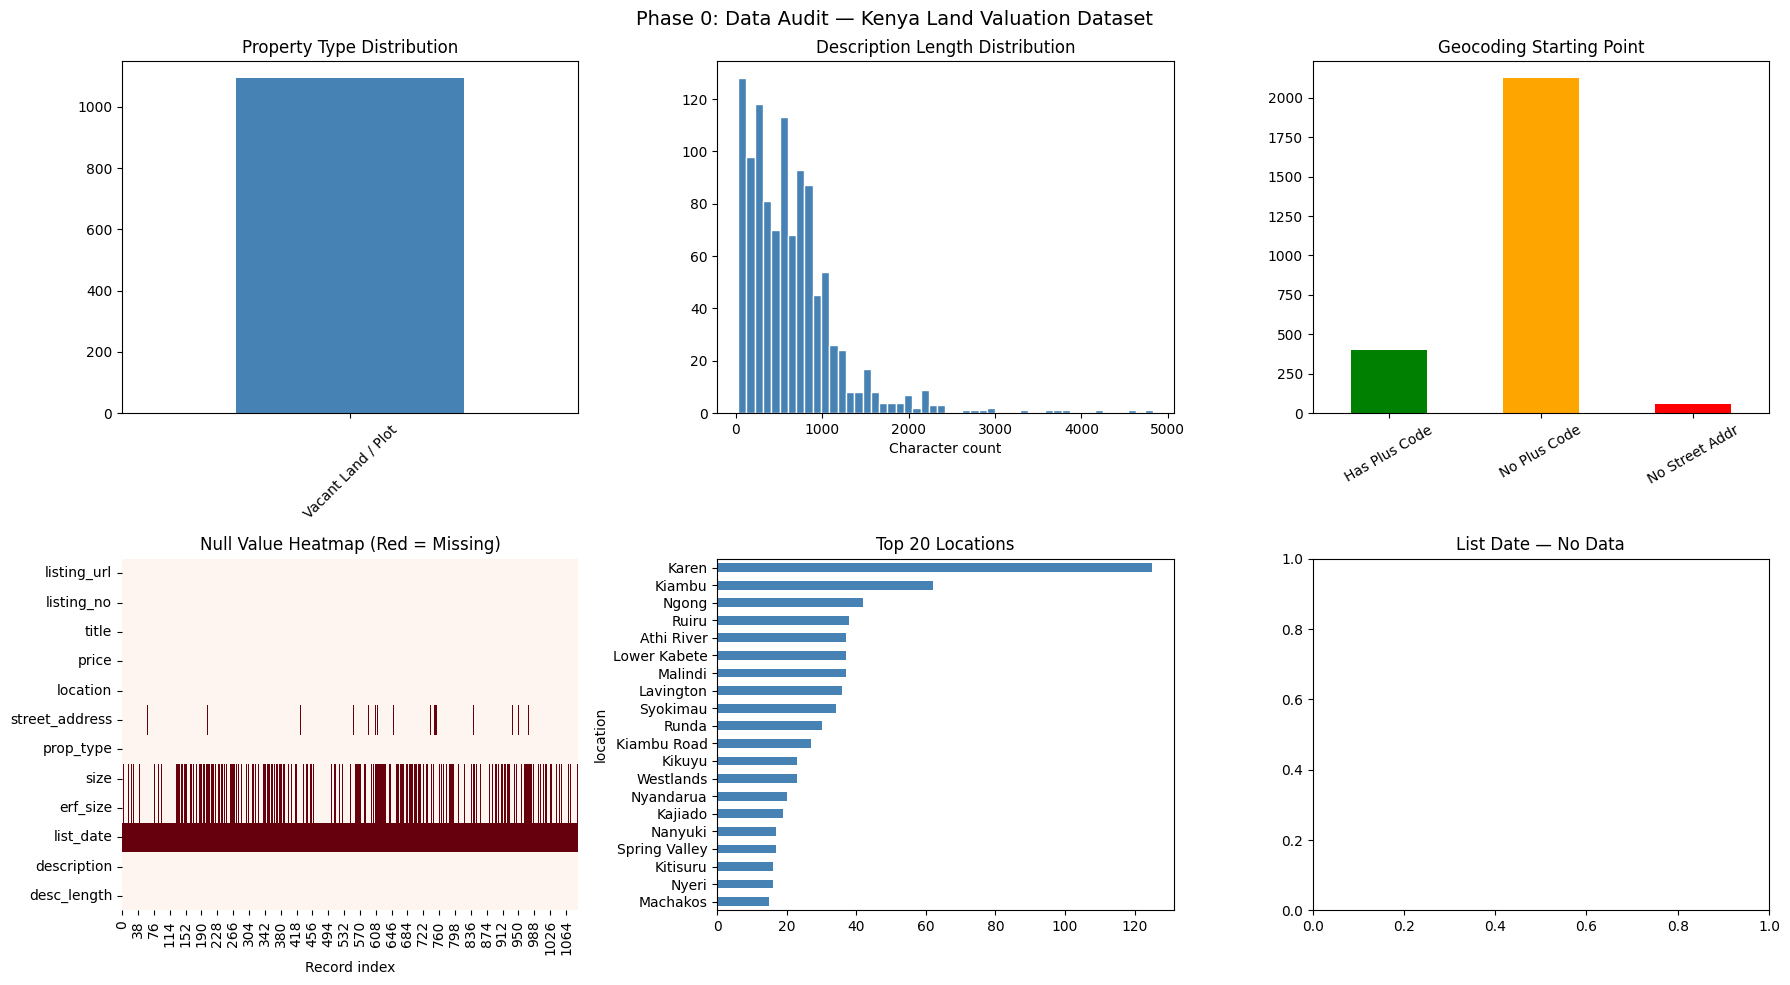

Audit chart saved to outputs folder


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Phase 0: Data Audit — Kenya Land Valuation Dataset", fontsize=14)

df["prop_type"].value_counts().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Property Type Distribution")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].hist(df["desc_length"], bins=50, color="steelblue", edgecolor="white")
axes[0, 1].set_title("Description Length Distribution")
axes[0, 1].set_xlabel("Character count")

geocode_preview = pd.Series({
    "Has Plus Code" : has_plus_code.sum(),
    "No Plus Code"  : (~has_plus_code).sum(),
    "No Street Addr": df["street_address"].isnull().sum()
})
geocode_preview.plot(kind="bar", ax=axes[0, 2], color=["green", "orange", "red"])
axes[0, 2].set_title("Geocoding Starting Point")
axes[0, 2].tick_params(axis="x", rotation=30)

sns.heatmap(df.isnull().astype(int).T, ax=axes[1, 0], cbar=False, cmap="Reds", yticklabels=True)
axes[1, 0].set_title("Null Value Heatmap (Red = Missing)")
axes[1, 0].set_xlabel("Record index")

df["location"].value_counts().head(20).plot(kind="barh", ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Top 20 Locations")
axes[1, 1].invert_yaxis()

if df["list_date"].notnull().sum() > 0:
    df["list_date"].dropna().plot(kind="hist", ax=axes[1, 2], bins=30, color="steelblue")
    axes[1, 2].set_title("Listing Date Distribution")
else:
    axes[1, 2].set_title("List Date — No Data")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/phase0_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Audit chart saved to outputs folder")

---
## Phase 1 — Price Standardisation

The raw `price` column contains mixed currencies (KSh and USD), shorthand notation (20M, 1.5B),
comma and space separators, and non-price strings (POA, negotiable). This phase parses every
value into a consistent float in KSh, assigns a quality flag per record, and produces a
log-transformed column ready for modelling.


### Cell 1.1 — Price Pattern Audit

Count how many records match each format before writing any parsing logic.
This drives the priority ordering of the cleaning function.


In [ ]:
print("=" * 65)
print("PRICE PATTERN AUDIT")
print("=" * 65)

print(f"\nNull prices     : {df['price'].isnull().sum()}")
print(f"Non-null prices : {df['price'].notnull().sum()}")

price_str = df["price"].dropna().astype(str).str.strip()

patterns = {
    "Contains 'KSh' or 'Ksh'" : price_str.str.contains(r'[Kk][Ss][Hh]', regex=True).sum(),
    "Contains 'USD' or '$'"   : price_str.str.contains(r'USD|\$', regex=True).sum(),
    "Contains 'M' shorthand"  : price_str.str.contains(r'\d+(\.\d+)?M', regex=True).sum(),
    "Contains 'B' shorthand"  : price_str.str.contains(r'\d+(\.\d+)?B', regex=True).sum(),
    "Price on Request / POA"  : price_str.str.contains(r'request|POA|negotiable', case=False, regex=True).sum(),
    "Contains comma separator": price_str.str.contains(r'\d,\d', regex=True).sum(),
    "Contains space separator": price_str.str.contains(r'\d \d', regex=True).sum(),
    "Numeric only (no symbol)": price_str.str.match(r'^\d[\d\s,\.]+$').sum(),
}

for label, count in patterns.items():
    print(f"  {label:<35}: {count:>6,}")

PRICE PATTERN AUDIT

Null prices     : 0
Non-null prices : 1094
  Contains 'KSh' or 'Ksh'            :  1,020
  Contains 'USD' or '$'              :      0
  Contains 'M' shorthand             :      0
  Contains 'B' shorthand             :      0
  Price on Request / POA             :     74
  Contains comma separator           :      0
  Contains space separator           :  1,019
  Numeric only (no symbol)           :      0


### Cell 1.2 — Price Cleaning Function

Handles every detected pattern in priority order. Returns both a numeric value and a quality flag
so you can filter or weight records downstream.

**USD exchange rate:** Update `USD_TO_KSH_RATE` if the rate has drifted significantly since the
date recorded in `USD_RATE_DATE`.


In [ ]:
USD_TO_KSH_RATE = 129.50   # Rate as of early 2025 — update if needed
USD_RATE_DATE   = "2025-01"

def clean_price(raw_value):
    """
    Parse a raw price string into a float in KSh.

    Returns
    -------
    (price_ksh : float | NaN, flag : str)

    Flags
    -----
    clean         : standard KSh value
    converted_usd : was USD, converted to KSh
    missing       : null, empty, or unparseable
    negotiable    : price on request / POA / negotiable
    ambiguous     : has digits but currency is unclear
    """
    if pd.isnull(raw_value):
        return np.nan, "missing"

    text = str(raw_value).strip()

    if text == "" or text.lower() in ["nan", "none", "-", "n/a"]:
        return np.nan, "missing"

    if re.search(r'request|poa|negotiable|contact|call', text, re.IGNORECASE):
        return np.nan, "negotiable"

    is_usd = bool(re.search(r'USD|\$|usd', text))
    is_ksh = bool(re.search(r'[Kk][Ss][Hh]|KES', text))

    # Handle M / B shorthand before stripping letters
    shorthand_match = re.search(r'([\d]+(?:\.[\d]+)?)\s*([MB])', text, re.IGNORECASE)
    if shorthand_match:
        number    = float(shorthand_match.group(1))
        suffix    = shorthand_match.group(2).upper()
        price_val = number * (1_000_000 if suffix == "M" else 1_000_000_000)
        flag      = "converted_usd" if is_usd else "clean"
        if is_usd:
            price_val *= USD_TO_KSH_RATE
        return price_val, flag

    numeric_str = re.sub(r'[^\d\.]', '', text)

    if numeric_str == "" or numeric_str == ".":
        return np.nan, "missing"

    # European-style thousand separators: "20.000.000" → "20000000"
    if numeric_str.count(".") > 1:
        parts = numeric_str.split(".")
        numeric_str = "".join(parts[:-1]) + "." + parts[-1]

    try:
        price_val = float(numeric_str)
    except ValueError:
        return np.nan, "ambiguous"

    # Values below 1,000 are almost certainly parsing errors for Kenyan land prices
    if price_val < 1_000:
        return np.nan, "ambiguous"

    if is_usd:
        return price_val * USD_TO_KSH_RATE, "converted_usd"

    if not is_ksh and not is_usd:
        return price_val, "ambiguous"

    return price_val, "clean"


### Cell 1.3 — Apply Price Cleaning


In [ ]:
print("Cleaning price column...")

results = df["price"].progress_apply(clean_price)
df["price_ksh"]  = results.apply(lambda x: x[0])
df["price_flag"] = results.apply(lambda x: x[1])

print("\nPrice flag distribution:")
print(df["price_flag"].value_counts())
print(f"\nSuccessfully parsed  : {df['price_ksh'].notnull().sum():,} records")
print(f"Unparseable / missing: {df['price_ksh'].isnull().sum():,} records")

Cleaning price column...


100%|██████████| 1094/1094 [00:00<00:00, 41096.32it/s]


Price flag distribution:
price_flag
clean         1019
negotiable      74
ambiguous        1
Name: count, dtype: int64

Successfully parsed  : 1,019 records
Unparseable / missing: 75 records


### Cell 1.4 — Log Transform

Land prices in Kenya span several orders of magnitude. The log transform compresses this range,
making the distribution closer to normal and improving MLP training stability.
Only applied where `price_ksh` is valid and positive.


In [ ]:
df["log_price_ksh"] = np.where(
    df["price_ksh"].notnull() & (df["price_ksh"] > 0),
    np.log(df["price_ksh"]),
    np.nan
)

print(f"Valid log_price_ksh values: {df['log_price_ksh'].notnull().sum():,}")

Valid log_price_ksh values: 1,019


### Cell 1.5 — Sanity Checks

Verify that the cleaned price range is plausible for Kenyan land. Flag anything below KSh 100,000
or above KSh 5 billion for manual review.


In [ ]:
print("=" * 65)
print("PRICE VALIDATION — SANITY CHECKS")
print("=" * 65)

clean_prices = df[df["price_flag"] == "clean"]["price_ksh"]

print(f"\nClean prices summary (KSh):")
print(f"  Count  : {clean_prices.count():,}")
print(f"  Min    : KSh {clean_prices.min():>20,.0f}")
print(f"  Max    : KSh {clean_prices.max():>20,.0f}")
print(f"  Median : KSh {clean_prices.median():>20,.0f}")
print(f"  Mean   : KSh {clean_prices.mean():>20,.0f}")
print(f"  Std    : KSh {clean_prices.std():>20,.0f}")

LOWER_BOUND = 100_000
UPPER_BOUND = 5_000_000_000

low_outliers  = df[(df["price_ksh"] < LOWER_BOUND) & df["price_ksh"].notnull()]
high_outliers = df[(df["price_ksh"] > UPPER_BOUND) & df["price_ksh"].notnull()]

print(f"\nSuspicious low prices  (< KSh 100K) : {len(low_outliers)}")
print(f"Suspicious high prices (> KSh 5B)   : {len(high_outliers)}")

if len(low_outliers) > 0:
    print("\nLow outlier samples:")
    print(low_outliers[["price", "price_ksh", "price_flag", "location"]].head(10).to_string())

if len(high_outliers) > 0:
    print("\nHigh outlier samples:")
    print(high_outliers[["price", "price_ksh", "price_flag", "location"]].head(10).to_string())

PRICE VALIDATION — SANITY CHECKS

Clean prices summary (KSh):
  Count  : 1,019
  Min    : KSh                3,000
  Max    : KSh        6,200,000,000
  Median : KSh           28,000,000
  Mean   : KSh          154,532,946
  Std    : KSh          418,446,729

Suspicious low prices  (< KSh 100K) : 4
Suspicious high prices (> KSh 5B)   : 2

Low outlier samples:
          price  price_ksh price_flag   location
84   KSh 50 000    50000.0      clean    Malindi
94    KSh 6 650     6650.0      clean    Kajiado
553   KSh 3 000     3000.0      clean     Migori
677   KSh 9 000     9000.0      clean  Kerarapon

High outlier samples:
                  price     price_ksh price_flag     location
796   KSh 6 200 000 000  6.200000e+09      clean  Kiambu Road
1001  KSh 6 200 000 000  6.200000e+09      clean  Kiambu Road


### Cell 1.6 — Visual Audit


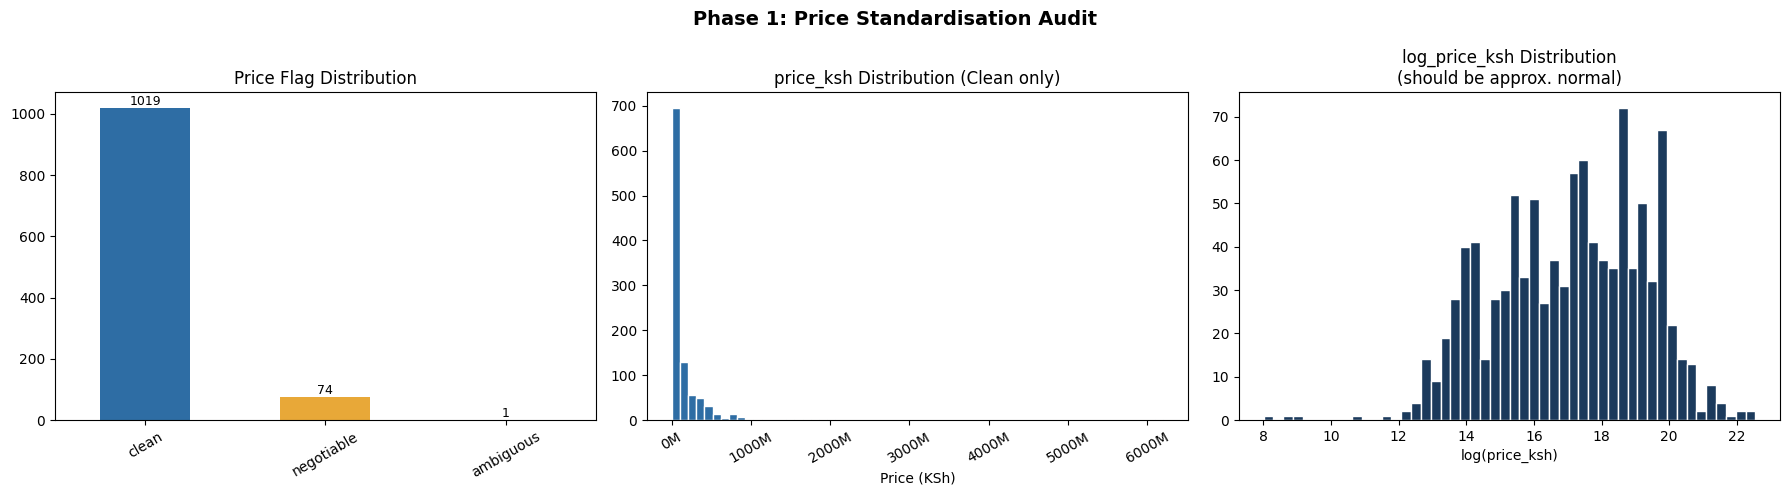

Chart saved to outputs folder.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Phase 1: Price Standardisation Audit", fontsize=14, fontweight="bold")

df["price_flag"].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#2E6DA4", "#E8A838", "#D9534F", "#5CB85C", "#9B59B6"]
)
axes[0].set_title("Price Flag Distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=9)

clean_mask = df["price_flag"] == "clean"
axes[1].hist(df.loc[clean_mask, "price_ksh"].dropna(), bins=60,
             color="#2E6DA4", edgecolor="white")
axes[1].set_title("price_ksh Distribution (Clean only)")
axes[1].set_xlabel("Price (KSh)")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[1].tick_params(axis="x", rotation=30)

axes[2].hist(df["log_price_ksh"].dropna(), bins=50,
             color="#1B3A5C", edgecolor="white")
axes[2].set_title("log_price_ksh Distribution\n(should be approx. normal)")
axes[2].set_xlabel("log(price_ksh)")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/phase1_price_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs folder.")

### Cell 1.7 — Review Ambiguous and Converted Records

Manually inspect records that were flagged as ambiguous (currency unclear) or converted from USD.
Ambiguous records may need a pricing source fix; USD conversions depend on the exchange rate used.


In [ ]:
print("=" * 65)
print("AMBIGUOUS PRICES — REVIEW THESE MANUALLY")
print("=" * 65)
ambiguous = df[df["price_flag"] == "ambiguous"][["price", "price_ksh", "location"]].head(20)
if len(ambiguous) > 0:
    print(ambiguous.to_string())
else:
    print("No ambiguous prices found.")

print("\n" + "=" * 65)
print("USD CONVERSIONS — VERIFY THESE")
print("=" * 65)
usd_records = df[df["price_flag"] == "converted_usd"][["price", "price_ksh", "location"]].head(20)
if len(usd_records) > 0:
    print(f"Exchange rate used: 1 USD = {USD_TO_KSH_RATE} KSh (as of {USD_RATE_DATE})")
    print(usd_records.to_string())
else:
    print("No USD prices found.")

AMBIGUOUS PRICES — REVIEW THESE MANUALLY
     price  price_ksh      location
995  KSh 1        NaN  Shimba Hills

USD CONVERSIONS — VERIFY THESE
No USD prices found.


### Cell 1.8 — Phase 1 Column Summary & Save Checkpoint


In [ ]:
print("=" * 65)
print("PHASE 1 OUTPUT — COLUMN SUMMARY")
print("=" * 65)

cols = ["price_ksh", "price_flag", "log_price_ksh"]
summary = pd.DataFrame({
    "dtype"   : [str(df[c].dtype) for c in cols],
    "non_null": [df[c].notnull().sum() for c in cols],
    "null"    : [df[c].isnull().sum() for c in cols],
}, index=cols)
print(summary.to_string())

print(f"\nRecords retained : {len(df):,}")
print(f"Prices parseable : {df['price_ksh'].notnull().sum():,} ({df['price_ksh'].notnull().sum()/len(df)*100:.1f}%)")

df.to_parquet(f"{INTERIM_DATA}/phase1_price.parquet", index=False)
print(f"\nCheckpoint saved: phase1_price.parquet")

PHASE 1 OUTPUT — COLUMN SUMMARY
                 dtype  non_null  null
price_ksh      float64      1019    75
price_flag      object      1094     0
log_price_ksh  float64      1019    75

Records retained : 1,094
Prices parseable : 1,019 (93.1%)

Checkpoint saved: phase1_price.parquet


---
## Phase 2 — Size Standardisation

The raw `size` column contains values in acres, hectares, square metres, square feet, and
Kenyan plot notation (e.g. 50x100). Text fractions such as "half acre" also appear.
This phase converts everything to decimal acres, with an NLP fallback that mines the
description text when the size column is missing.


### Cell 2.1 — Size Pattern Audit


In [ ]:
size_str = df["size"].dropna().astype(str).str.strip()

patterns = {
    "Acres"          : size_str.str.contains(r'acres?', case=False, regex=True).sum(),
    "Hectares"       : size_str.str.contains(r'ha|hectares?', case=False, regex=True).sum(),
    "Sq meters"      : size_str.str.contains(r'sq\.?\s*m|square\s*met', case=False, regex=True).sum(),
    "Sq feet"        : size_str.str.contains(r'sq\.?\s*ft|square\s*f', case=False, regex=True).sum(),
    "50x100 notation": size_str.str.contains(r'\d+\s*(by|x)\s*\d+', case=False, regex=True).sum(),
    "Text fractions" : size_str.str.contains(r'half|quarter|one\s*and', case=False, regex=True).sum(),
    "Nulls"          : df["size"].isnull().sum(),
}

for label, count in patterns.items():
    print(f"  {label:<25}: {count:>5,}")

  Acres                    :   622
  Hectares                 :    18
  Sq meters                :     0
  Sq feet                  :     0
  50x100 notation          :     0
  Text fractions           :     0
  Nulls                    :   454


### Cell 2.2 — Size Cleaning Function

Unit conversion constants are defined at the top. The function normalises text fractions,
handles Kenyan 50x100 plot notation, extracts the leading number, then converts to acres
based on the detected unit. Records with no unit default to acres, which is the conventional
unit for Kenyan land listings.


In [ ]:
HA_TO_ACRES      = 2.4711
SQM_TO_ACRES     = 0.000247105
SQFT_TO_ACRES    = 0.0000229568
PLOT_50x100_ACRES = 0.1148   # 50x100 ft = 5,000 sqft

def clean_size(raw):
    """
    Parse a raw size string into decimal acres.

    Returns
    -------
    (size_acres : float | NaN, source : str)

    Source values: 'column' | 'missing'
    """
    if pd.isnull(raw):
        return np.nan, "missing"

    text = str(raw).strip().lower()

    if text in ["", "nan", "none", "-"]:
        return np.nan, "missing"

    text = re.sub(r'one\s*and\s*a?\s*half', '1.5', text)
    text = re.sub(r'\bhalf\b',               '0.5', text)
    text = re.sub(r'\bquarter\b',            '0.25', text)
    text = re.sub(r'\bthree\s*quarter',      '0.75', text)

    plot_match = re.search(r'(\d+)\s*(?:by|x)\s*(\d+)', text)
    if plot_match:
        sqft = float(plot_match.group(1)) * float(plot_match.group(2))
        return round(sqft * SQFT_TO_ACRES, 6), "column"

    num_match = re.search(r'([\d]+(?:\.[\d]+)?)', text)
    if not num_match:
        return np.nan, "missing"

    val = float(num_match.group(1))

    if re.search(r'ha\b|hectare', text):
        return round(val * HA_TO_ACRES, 4), "column"
    if re.search(r'sq\.?\s*m|square\s*met|sqm', text):
        return round(val * SQM_TO_ACRES, 6), "column"
    if re.search(r'sq\.?\s*ft|square\s*f|sqft', text):
        return round(val * SQFT_TO_ACRES, 6), "column"
    if re.search(r'acres?', text):
        return round(val, 4), "column"

    return round(val, 4), "column"  # default: assume acres

### Cell 2.3 — Apply to Size Column


In [ ]:
results           = df["size"].apply(clean_size)
df["size_acres"]  = results.apply(lambda x: x[0])
df["size_source"] = results.apply(lambda x: x[1])

print("Size source breakdown after column cleaning:")
print(df["size_source"].value_counts())
print(f"\nMissing after column pass: {df['size_acres'].isnull().sum()}")

Size source breakdown after column cleaning:
size_source
column     640
missing    454
Name: count, dtype: int64

Missing after column pass: 454


### Cell 2.4 — NLP Fallback from Description

For records where the size column could not be parsed, attempt to extract a size value
from the free-text description. The same unit conversion logic is applied.
This fallback is only triggered for the records that remain null after Cell 2.3.


In [ ]:
def extract_size_from_description(text):
    """
    Mine the description for size mentions as a fallback.
    Returns (size_acres : float | NaN, source : str).
    """
    if pd.isnull(text) or len(str(text)) < 20:
        return np.nan, "missing"

    text = str(text).lower()
    text = re.sub(r'one\s*and\s*a?\s*half', '1.5', text)
    text = re.sub(r'\bhalf\b',               '0.5', text)
    text = re.sub(r'\bquarter\b',            '0.25', text)

    plot_match = re.search(r'(\d+)\s*(?:by|x)\s*(\d+)', text)
    if plot_match:
        sqft = float(plot_match.group(1)) * float(plot_match.group(2))
        return round(sqft * SQFT_TO_ACRES, 6), "nlp_description"

    m = re.search(r'([\d]+(?:\.[\d]+)?)\s*[-]?\s*acres?', text)
    if m:
        return round(float(m.group(1)), 4), "nlp_description"

    m = re.search(r'([\d]+(?:\.[\d]+)?)\s*(?:ha|hectares?)', text)
    if m:
        return round(float(m.group(1)) * HA_TO_ACRES, 4), "nlp_description"

    m = re.search(r'([\d]+(?:\.[\d]+)?)\s*(?:sq\.?\s*m|sqm|square\s*met)', text)
    if m:
        return round(float(m.group(1)) * SQM_TO_ACRES, 6), "nlp_description"

    return np.nan, "missing"


missing_mask = df["size_acres"].isnull()
print(f"Records needing NLP fallback: {missing_mask.sum()}")

if missing_mask.sum() > 0:
    fallback = df.loc[missing_mask, "description"].apply(extract_size_from_description)
    df.loc[missing_mask, "size_acres"]  = fallback.apply(lambda x: x[0])
    df.loc[missing_mask, "size_source"] = fallback.apply(lambda x: x[1])

print("\nSize source breakdown after NLP fallback:")
print(df["size_source"].value_counts())

Records needing NLP fallback: 454

Size source breakdown after NLP fallback:
size_source
column             640
missing            273
nlp_description    181
Name: count, dtype: int64


### Cell 2.5 — Log Transform


In [ ]:
df["log_size_acres"] = np.where(
    df["size_acres"].notnull() & (df["size_acres"] > 0),
    np.log(df["size_acres"]),
    np.nan
)

print(f"Valid log_size_acres values: {df['log_size_acres'].notnull().sum():,}")

Valid log_size_acres values: 817


### Cell 2.6 — Sanity Checks

Flag sizes below 0.05 acres (roughly 2,178 sqft — smaller than the smallest practical Kenyan plot)
and above 50,000 acres (a generous upper bound for large ranches).


In [ ]:
low_flag  = df[(df["size_acres"] < 0.05)   & df["size_acres"].notnull()]
high_flag = df[(df["size_acres"] > 50_000) & df["size_acres"].notnull()]

print(f"Suspiciously small (< 0.05 acres) : {len(low_flag)}")
print(f"Suspiciously large (> 50,000 acres): {len(high_flag)}")

if len(low_flag)  > 0:
    print(low_flag[["size", "size_acres", "location"]].to_string())
if len(high_flag) > 0:
    print(high_flag[["size", "size_acres", "location"]].to_string())

Suspiciously small (< 0.05 acres) : 5
Suspiciously large (> 50,000 acres): 0
           size  size_acres  location
24          NaN      0.0000  Naivasha
307   000 Acres      0.0000     Ruiru
336   000 acres      0.0000       Voi
369   0.0197 Ha      0.0487   Malindi
1079  000 Acres      0.0000   Kericho


### Cell 2.7 — Visual Audit


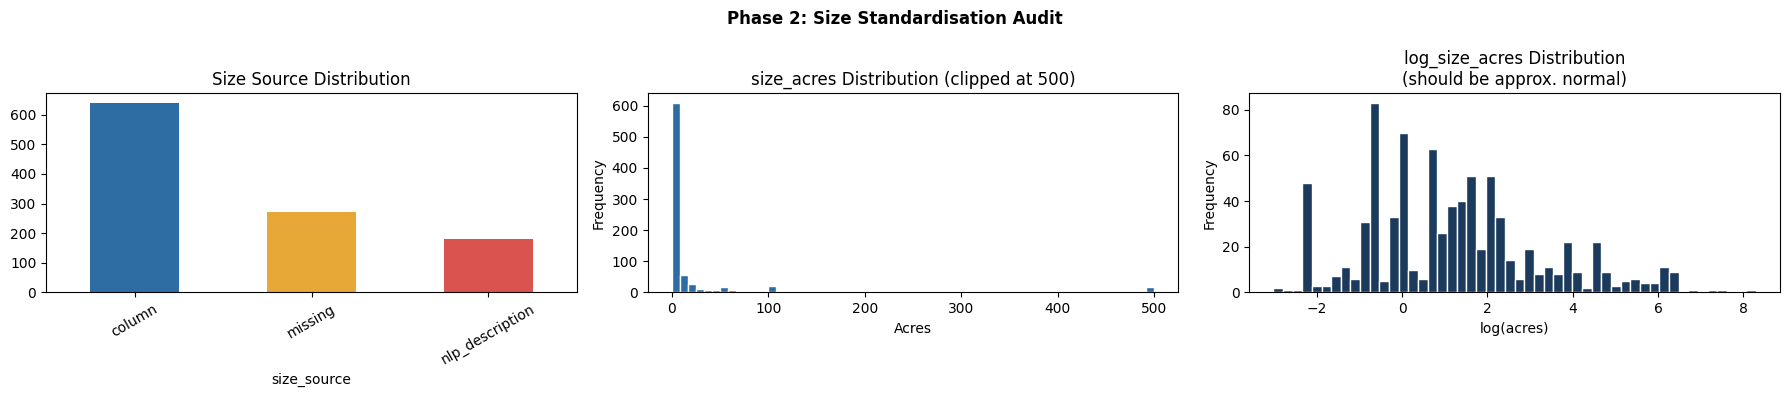

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Phase 2: Size Standardisation Audit", fontweight="bold")

df["size_source"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#2E6DA4", "#E8A838", "#D9534F"]
)
axes[0].set_title("Size Source Distribution")
axes[0].tick_params(axis="x", rotation=30)

df["size_acres"].dropna().clip(upper=500).plot(
    kind="hist", bins=60, ax=axes[1], color="#2E6DA4", edgecolor="white"
)
axes[1].set_title("size_acres Distribution (clipped at 500)")
axes[1].set_xlabel("Acres")

df["log_size_acres"].dropna().plot(
    kind="hist", bins=50, ax=axes[2], color="#1B3A5C", edgecolor="white"
)
axes[2].set_title("log_size_acres Distribution\n(should be approx. normal)")
axes[2].set_xlabel("log(acres)")

plt.tight_layout()
plt.show()

### Cell 2.8 — Phase 2 Summary & Save Checkpoint


In [ ]:
print("=" * 55)
print("PHASE 1 + 2 COMBINED COLUMN SUMMARY")
print("=" * 55)

cols = ["price_ksh", "price_flag", "log_price_ksh",
        "size_acres", "size_source", "log_size_acres"]

summary = pd.DataFrame({
    "dtype"   : [str(df[c].dtype) for c in cols],
    "non_null": [df[c].notnull().sum() for c in cols],
    "null"    : [df[c].isnull().sum() for c in cols],
    "null_pct": [(df[c].isnull().sum() / len(df) * 100).round(1) for c in cols],
}, index=cols)
print(summary.to_string())

df.to_parquet(f"{INTERIM_DATA}/phase2_size.parquet", index=False)
print("\nCheckpoint saved: phase2_size.parquet")

PHASE 1 + 2 COMBINED COLUMN SUMMARY
                  dtype  non_null  null  null_pct
price_ksh       float64      1019    75       6.9
price_flag       object      1094     0       0.0
log_price_ksh   float64      1019    75       6.9
size_acres      float64       821   273      25.0
size_source      object      1094     0       0.0
log_size_acres  float64       817   277      25.3

Checkpoint saved: phase2_size.parquet


---
## Phase 3 — Geocoding

Assigns latitude and longitude to each listing using a five-level waterfall:

1. **Plus Code** — exact coordinates from an Open Location Code in the street address (confidence 1.0)
2. **Street address** — Nominatim geocoding of the full street address (confidence 0.8)
3. **NLP landmarks** — place names and proximity hints extracted from the description (confidence 0.5)
4. **Location town** — Nominatim geocoding of the `location` column value (confidence 0.3)
5. **County centroid** — fallback to the county's geographic centre (confidence 0.2)

Each record is tagged with a `geocode_source` and `geocode_confidence` for downstream filtering.


### Cell 3.1 — Fix Encoding Artifacts

Correct common UTF-8 mojibake characters that appear in scraped text before any string matching.


In [ ]:
def fix_encoding(text):
    if pd.isnull(text):
        return text
    text = str(text)
    replacements = {
        "â€™": "'", "â€œ": '"', "â€": '"',
        "â€˜": "'", "â€": "-", "â€¢": "•",
        "Â": "", "â€": ""
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return text.strip()

df["street_address"] = df["street_address"].apply(fix_encoding)
df["location"]       = df["location"].apply(fix_encoding)
df["description"]    = df["description"].apply(fix_encoding)

print("Encoding artifacts cleaned.")

Encoding artifacts cleaned.


### Cell 3.2 — County Centroids

Reference coordinates for the 47 Kenyan counties used as the Level 5 fallback when all
higher-confidence geocoding methods fail.


In [ ]:
COUNTY_CENTROIDS = {
    "Nairobi"        : (-1.2921, 36.8219), "Mombasa"        : (-4.0435, 39.6682),
    "Kwale"          : (-4.1816, 39.4600), "Kilifi"         : (-3.5107, 39.9093),
    "Tana River"     : (-1.4000, 40.0000), "Lamu"           : (-2.2686, 40.9020),
    "Taita Taveta"   : (-3.4000, 38.5000), "Garissa"        : (-0.4532, 39.6461),
    "Wajir"          : ( 1.7471, 40.0573), "Mandera"        : ( 3.9366, 41.8670),
    "Marsabit"       : ( 2.3284, 37.9899), "Isiolo"         : ( 0.3540, 37.5820),
    "Meru"           : ( 0.0470, 37.6490), "Tharaka Nithi"  : (-0.3000, 37.8800),
    "Embu"           : (-0.5300, 37.4500), "Kitui"          : (-1.3671, 38.0106),
    "Machakos"       : (-1.5177, 37.2634), "Makueni"        : (-1.8036, 37.6200),
    "Nyandarua"      : (-0.1800, 36.5200), "Nyeri"          : (-0.4167, 36.9500),
    "Kirinyaga"      : (-0.5600, 37.2800), "Murang'a"       : (-0.7833, 37.0333),
    "Kiambu"         : (-1.0300, 36.8300), "Turkana"        : ( 3.1000, 35.6000),
    "West Pokot"     : ( 1.6200, 35.1200), "Samburu"        : ( 1.2000, 36.9900),
    "Trans Nzoia"    : ( 1.0566, 35.0010), "Uasin Gishu"    : ( 0.5200, 35.2699),
    "Elgeyo Marakwet": ( 0.7000, 35.5000), "Nandi"          : ( 0.1800, 35.1700),
    "Baringo"        : ( 0.8500, 35.9700), "Laikipia"       : ( 0.2000, 36.8000),
    "Nakuru"         : (-0.3031, 36.0800), "Narok"          : (-1.0800, 35.8700),
    "Kajiado"        : (-1.8500, 36.7800), "Kericho"        : (-0.3670, 35.2860),
    "Bomet"          : (-0.7800, 35.3400), "Kakamega"       : ( 0.2827, 34.7519),
    "Vihiga"         : ( 0.0800, 34.7200), "Bungoma"        : ( 0.5600, 34.5600),
    "Busia"          : ( 0.4600, 34.1100), "Siaya"          : (-0.0617, 34.2900),
    "Kisumu"         : (-0.1022, 34.7617), "Homa Bay"       : (-0.5200, 34.4600),
    "Migori"         : (-1.0634, 34.4731), "Kisii"          : (-0.6817, 34.7667),
    "Nyamira"        : (-0.5700, 34.9300),
}

print(f"County centroids loaded: {len(COUNTY_CENTROIDS)}")

County centroids loaded: 47


### Cell 3.3 — Geocoding Waterfall Functions

Three helper functions:
- `decode_plus_code` — decodes an Open Location Code to coordinates
- `extract_nlp_locations` — extracts place names and proximity hints from description text
- `geocode_row` — runs the full five-level waterfall for a single row


In [ ]:
from openlocationcode import openlocationcode as olc
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

PLUS_CODE_PATTERN = r'[A-Z0-9]{4}\+[A-Z0-9]{2,3}'
KE_BOUNDS         = {"lat": (-4.72, 4.62), "lon": (33.91, 41.91)}

geolocator = Nominatim(user_agent="kenya_land_valuation_v1", timeout=10)
geocode    = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)


def within_kenya(lat, lon):
    return (KE_BOUNDS["lat"][0] <= lat <= KE_BOUNDS["lat"][1] and
            KE_BOUNDS["lon"][0] <= lon <= KE_BOUNDS["lon"][1])


def decode_plus_code(text):
    """Return (lat, lon) from a Plus Code in the text, or None."""
    if pd.isnull(text):
        return None
    match = re.search(PLUS_CODE_PATTERN, str(text))
    if match:
        try:
            coord = olc.decode(match.group())
            return (coord.latitudeCenter, coord.longitudeCenter)
        except Exception:
            return None
    return None


def geocode_safe(query):
    """Query Nominatim and return (lat, lon) if the result is within Kenya."""
    try:
        result = geocode(f"{query}, Kenya")
        if result and within_kenya(result.latitude, result.longitude):
            return (result.latitude, result.longitude)
    except Exception:
        pass
    return None


def extract_nlp_locations(text):
    """Extract GPE/LOC entities and proximity hints from description text."""
    if pd.isnull(text) or len(str(text)) < 30:
        return []
    doc = nlp(str(text)[:1000])
    locations = [ent.text for ent in doc.ents if ent.label_ in ("GPE", "LOC")]
    prox = re.findall(
        r'\d+\s*(?:m|km|meters?|kilometres?)\s+(?:from|off|to)\s+([A-Za-z\s\-]+)',
        str(text), re.IGNORECASE
    )
    return [p.strip() for p in prox] + locations


def geocode_row(row):
    """
    Five-level waterfall. Returns (lat, lon, source, confidence).
    """
    addr = row.get("street_address", "")
    loc  = row.get("location", "")
    desc = row.get("description", "")

    result = decode_plus_code(addr)
    if result:
        return (*result, "plus_code", 1.0)

    if not pd.isnull(addr) and len(str(addr)) > 5:
        result = geocode_safe(str(addr))
        if result:
            return (*result, "street_address", 0.8)

    for candidate in extract_nlp_locations(desc)[:3]:
        result = geocode_safe(candidate)
        if result:
            return (*result, "nlp_landmark", 0.5)

    if not pd.isnull(loc) and len(str(loc)) > 2:
        result = geocode_safe(str(loc))
        if result:
            return (*result, "location_town", 0.3)

    for county, coords in COUNTY_CENTROIDS.items():
        if not pd.isnull(loc) and county.lower() in str(loc).lower():
            return (*coords, "county_centroid", 0.2)

    return (np.nan, np.nan, "failed", 0.0)

### Cell 3.4 — Run Geocoding Waterfall

This cell makes live HTTP requests to Nominatim and will take approximately 20 to 45 minutes
for a dataset of ~2,600 records. The rate limiter enforces a 1.1 second pause between requests
to comply with Nominatim's usage policy. Do not interrupt the cell mid-run.


In [ ]:
print("Starting geocoding waterfall...")
print("Expected time: 20-45 minutes for ~2,600 records\n")

results = df.progress_apply(geocode_row, axis=1)

df["latitude"]           = results.apply(lambda x: x[0])
df["longitude"]          = results.apply(lambda x: x[1])
df["geocode_source"]     = results.apply(lambda x: x[2])
df["geocode_confidence"] = results.apply(lambda x: x[3])

print("\nGeocoding complete.")
print("\nSource breakdown:")
print(df["geocode_source"].value_counts().to_string())

Starting geocoding waterfall...
Expected time: 20-45 minutes for ~2,600 records



100%|██████████| 1094/1094 [27:40<00:00,  1.52s/it]


Geocoding complete.

Source breakdown:
geocode_source
street_address     747
nlp_landmark       232
location_town      112
county_centroid      2
failed               1


### Cell 3.5 — Validate Coordinates

Check for any coordinates that fall outside Kenya's bounding box, which would indicate
a Nominatim result matched a different country with a similarly named location.


In [ ]:
outside_kenya = df[
    df["latitude"].notnull() &
    ~df.apply(
        lambda r: within_kenya(r["latitude"], r["longitude"])
                  if pd.notnull(r["latitude"]) else False,
        axis=1
    )
]
print(f"Coordinates outside Kenya bounding box: {len(outside_kenya)}")
if len(outside_kenya) > 0:
    print(outside_kenya[["location", "street_address", "latitude", "longitude"]].to_string())

Coordinates outside Kenya bounding box: 0


### Cell 3.6 — Visual Audit


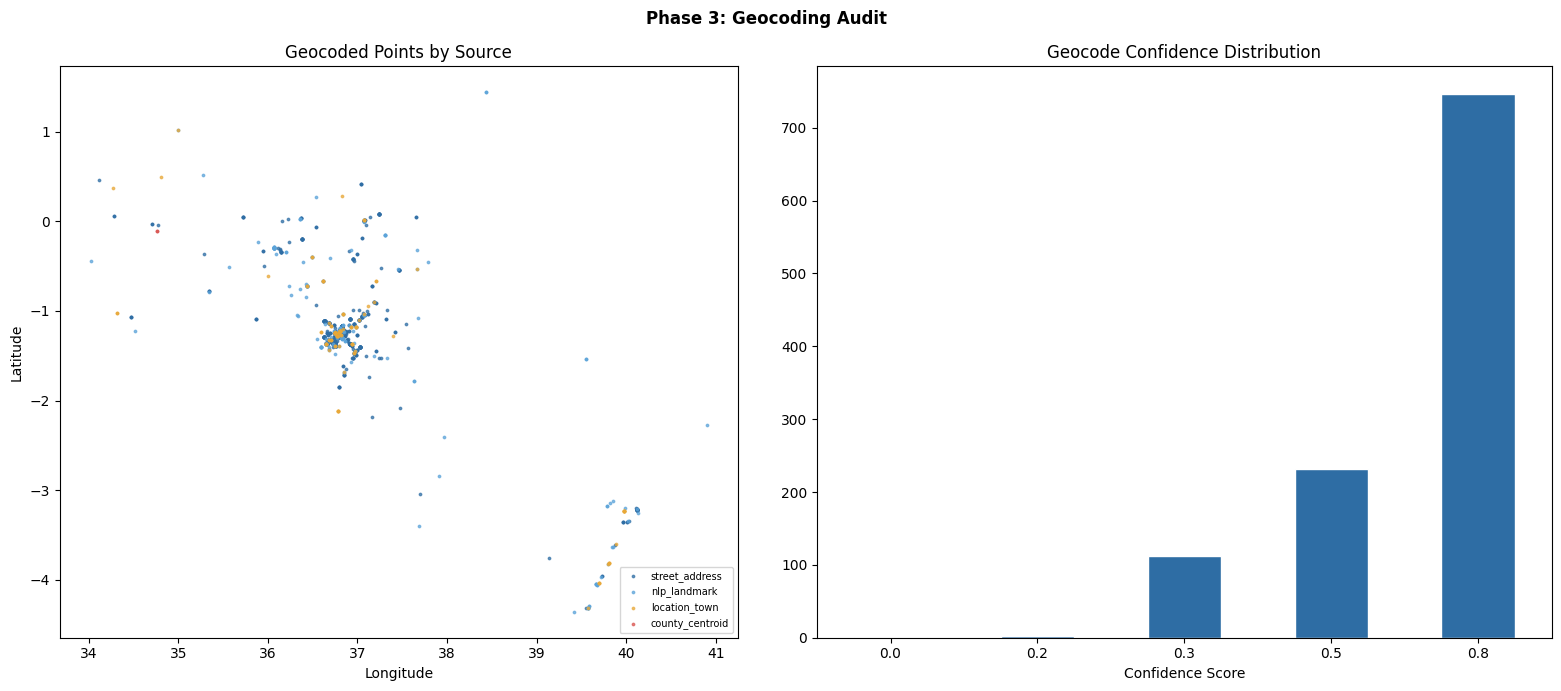

In [ ]:
valid = df[df["latitude"].notnull()].copy()
gdf   = gpd.GeoDataFrame(
    valid,
    geometry=[Point(xy) for xy in zip(valid["longitude"], valid["latitude"])],
    crs="EPSG:4326"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Phase 3: Geocoding Audit", fontweight="bold")

colors = {
    "plus_code"      : "#1B3A5C", "street_address": "#2E6DA4",
    "nlp_landmark"   : "#5BA3D9", "location_town" : "#E8A838",
    "county_centroid": "#D9534F", "failed"         : "#cccccc"
}
for source, color in colors.items():
    subset = gdf[gdf["geocode_source"] == source]
    if len(subset) > 0:
        subset.plot(ax=axes[0], color=color, markersize=3, label=source, alpha=0.7)

axes[0].set_title("Geocoded Points by Source")
axes[0].legend(loc="lower right", fontsize=7)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

df["geocode_confidence"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#2E6DA4", edgecolor="white"
)
axes[1].set_title("Geocode Confidence Distribution")
axes[1].set_xlabel("Confidence Score")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Cell 3.7 — Phase 3 Summary & Save Checkpoint


In [ ]:
print("=" * 55)
print("PHASE 3 SUMMARY")
print("=" * 55)
print(f"Total records         : {len(df):,}")
print(f"Successfully geocoded : {df['latitude'].notnull().sum():,}")
print(f"Failed                : {(df['geocode_source'] == 'failed').sum():,}")
print(f"\nSource breakdown:")
print(df["geocode_source"].value_counts().to_string())

df.to_parquet(f"{INTERIM_DATA}/phase3_geocoded.parquet", index=False)
print("\nCheckpoint saved: phase3_geocoded.parquet")

PHASE 3 SUMMARY
Total records         : 1,094
Successfully geocoded : 1,093
Failed                : 1

Source breakdown:
geocode_source
street_address     747
nlp_landmark       232
location_town      112
county_centroid      2
failed               1

Checkpoint saved: phase3_geocoded.parquet


---
## Phase 4 — Proximity Features

Computes three distance-based features for each listing:

- `dist_to_nairobi_km` — straight-line distance to Nairobi CBD
- `dist_to_county_town_km` — distance to the principal town of the listing's county
- `dist_to_water_body_km` — distance to the nearest significant water body (only for counties that border one)

A reference city is also assigned per listing. For properties in Nairobi-adjacent counties
(Kiambu, Kajiado, Machakos, Murang'a), Nairobi is used as the reference if it is physically
closer than the county town. This reflects how buyers in those areas actually think about location.


### Cell 4.1 — Reference Data: County Towns and Water Bodies


In [ ]:
from math import radians, sin, cos, sqrt, atan2

COUNTY_TOWNS = {
    "Nairobi"        : (-1.2921,  36.8219), "Mombasa"        : (-4.0435,  39.6682),
    "Kwale"          : (-4.1816,  39.4600), "Kilifi"         : (-3.5107,  39.9093),
    "Tana River"     : (-1.4000,  40.0000), "Lamu"           : (-2.2686,  40.9020),
    "Taita Taveta"   : (-3.4000,  38.5000), "Garissa"        : (-0.4532,  39.6461),
    "Wajir"          : ( 1.7471,  40.0573), "Mandera"        : ( 3.9366,  41.8670),
    "Marsabit"       : ( 2.3284,  37.9899), "Isiolo"         : ( 0.3540,  37.5820),
    "Meru"           : ( 0.0470,  37.6490), "Tharaka Nithi"  : (-0.3000,  37.8800),
    "Embu"           : (-0.5300,  37.4500), "Kitui"          : (-1.3671,  38.0106),
    "Machakos"       : (-1.5177,  37.2634), "Makueni"        : (-1.8036,  37.6200),
    "Nyandarua"      : (-0.1800,  36.5200), "Nyeri"          : (-0.4167,  36.9500),
    "Kirinyaga"      : (-0.5600,  37.2800), "Murang'a"       : (-0.7833,  37.0333),
    "Kiambu"         : (-1.0300,  36.8300), "Turkana"        : ( 3.1000,  35.6000),
    "West Pokot"     : ( 1.6200,  35.1200), "Samburu"        : ( 1.2000,  36.9900),
    "Trans Nzoia"    : ( 1.0566,  35.0010), "Uasin Gishu"    : ( 0.5200,  35.2699),
    "Elgeyo Marakwet": ( 0.7000,  35.5000), "Nandi"          : ( 0.1800,  35.1700),
    "Baringo"        : ( 0.8500,  35.9700), "Laikipia"       : ( 0.2000,  36.8000),
    "Nakuru"         : (-0.3031,  36.0800), "Narok"          : (-1.0800,  35.8700),
    "Kajiado"        : (-1.8500,  36.7800), "Kericho"        : (-0.3670,  35.2860),
    "Bomet"          : (-0.7800,  35.3400), "Kakamega"       : ( 0.2827,  34.7519),
    "Vihiga"         : ( 0.0800,  34.7200), "Bungoma"        : ( 0.5600,  34.5600),
    "Busia"          : ( 0.4600,  34.1100), "Siaya"          : (-0.0617,  34.2900),
    "Kisumu"         : (-0.1022,  34.7617), "Homa Bay"       : (-0.5200,  34.4600),
    "Migori"         : (-1.0634,  34.4731), "Kisii"          : (-0.6817,  34.7667),
    "Nyamira"        : (-0.5700,  34.9300),
}

NAIROBI_CBD      = (-1.2921, 36.8219)
NAIROBI_ADJACENT = {"Kiambu", "Kajiado", "Machakos", "Murang'a"}

WATER_BODIES = {
    "Mombasa" : [("Indian Ocean",  -4.0500,  39.6800)],
    "Kilifi"  : [("Indian Ocean",  -3.5100,  40.0200)],
    "Kwale"   : [("Indian Ocean",  -4.2500,  39.5600)],
    "Lamu"    : [("Indian Ocean",  -2.2700,  40.9000)],
    "Kisumu"  : [("Lake Victoria", -0.0917,  34.7500)],
    "Siaya"   : [("Lake Victoria", -0.0600,  34.2000)],
    "Homa Bay": [("Lake Victoria", -0.5300,  34.4500)],
    "Migori"  : [("Lake Victoria", -1.0700,  34.2300)],
    "Busia"   : [("Lake Victoria",  0.4600,  34.0500)],
    "Nakuru"  : [("Lake Nakuru",   -0.3700,  36.0900),
                 ("Lake Naivasha", -0.7700,  36.4300)],
    "Baringo" : [("Lake Baringo",   0.6300,  36.0400)],
    "Narok"   : [("Lake Natron",   -2.4200,  36.0000)],
}

print(f"County towns  : {len(COUNTY_TOWNS)}")
print(f"Water counties: {len(WATER_BODIES)}")

County towns  : 47
Water counties: 12


### Cell 4.2 — Haversine Distance Function

Computes the great-circle distance in kilometres between two coordinate pairs.
Used for all proximity calculations in this phase.


In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Return the great-circle distance in km between two points."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

### Cell 4.3 — Extract County from Location Column

Attempt a simple string match of county names within the `location` field.
This is a coarse first pass; Phase 4B replaces it with a spatial join and API lookup.


In [ ]:
def extract_county(location_text):
    if pd.isnull(location_text):
        return None
    text = str(location_text).lower()
    for county in COUNTY_TOWNS:
        if county.lower() in text:
            return county
    return None

df["county"] = df["location"].apply(extract_county)

print("County extraction (top 15):")
print(df["county"].value_counts().head(15).to_string())
print(f"\nUnmatched (county = None): {df['county'].isnull().sum()}")

County extraction (top 15):
county
Kiambu       89
Nyandarua    20
Kajiado      19
Nyeri        16
Machakos     15
Embu         13
Mombasa       9
Nakuru        8
Kisumu        7
Laikipia      5
Migori        5
Narok         3
Kilifi        3
Bomet         3
Siaya         2

Unmatched (county = None): 868


### Cell 4.4 — Compute All Proximity Features


In [ ]:
df["dist_to_nairobi_km"] = df.apply(
    lambda r: round(haversine_km(r["latitude"], r["longitude"],
                                 NAIROBI_CBD[0], NAIROBI_CBD[1]), 2)
              if pd.notnull(r["latitude"]) else np.nan,
    axis=1
)

df["dist_to_county_town_km"] = df.apply(
    lambda r: round(haversine_km(r["latitude"], r["longitude"],
                                 *COUNTY_TOWNS[r["county"]]), 2)
              if pd.notnull(r["latitude"]) and pd.notnull(r["county"])
                 and r["county"] in COUNTY_TOWNS
              else np.nan,
    axis=1
)

df["dist_to_water_body_km"] = df.apply(
    lambda r: round(min(
        haversine_km(r["latitude"], r["longitude"], wlat, wlon)
        for _, wlat, wlon in WATER_BODIES[r["county"]]
    ), 2) if pd.notnull(r["latitude"]) and r.get("county") in WATER_BODIES
    else np.nan,
    axis=1
)

print(f"dist_to_nairobi_km     — non-null: {df['dist_to_nairobi_km'].notnull().sum():,}")
print(f"dist_to_county_town_km — non-null: {df['dist_to_county_town_km'].notnull().sum():,}")
print(f"dist_to_water_body_km  — non-null: {df['dist_to_water_body_km'].notnull().sum():,}")

dist_to_nairobi_km     — non-null: 1,093
dist_to_county_town_km — non-null: 226
dist_to_water_body_km  — non-null: 41


### Cell 4.5 — Assign Reference City

For each listing, determine which city it should be measured against for modelling.
Properties in Nairobi-adjacent counties that are physically closer to Nairobi than
their county town are assigned Nairobi as the reference city.


In [ ]:
def get_reference_city(row):
    """
    Returns (reference_city : str, reference_city_dist_km : float).
    Nairobi-adjacent counties use Nairobi if it is the closer city.
    """
    county       = row.get("county")
    dist_nairobi = row.get("dist_to_nairobi_km")
    dist_town    = row.get("dist_to_county_town_km")

    if pd.isnull(row.get("latitude")):
        return np.nan, np.nan

    if (county in NAIROBI_ADJACENT
            and pd.notnull(dist_nairobi) and pd.notnull(dist_town)
            and dist_nairobi < dist_town):
        return "Nairobi", dist_nairobi

    if pd.notnull(dist_town) and pd.notnull(county):
        return county, dist_town

    if pd.notnull(dist_nairobi):
        return "Nairobi", dist_nairobi

    return np.nan, np.nan

ref_results = df.apply(get_reference_city, axis=1)
df["reference_city"]         = ref_results.apply(lambda x: x[0])
df["reference_city_dist_km"] = ref_results.apply(lambda x: x[1])

print("Reference city breakdown (top 15):")
print(df["reference_city"].value_counts().head(15).to_string())

Reference city breakdown (top 15):
reference_city
Nairobi      943
Kiambu        28
Nyandarua     20
Nyeri         16
Embu          13
Kajiado       10
Machakos      10
Mombasa        9
Nakuru         8
Kisumu         7
Migori         5
Laikipia       5
Narok          3
Kilifi         3
Bomet          3


### Cell 4.6 — Visual Audit


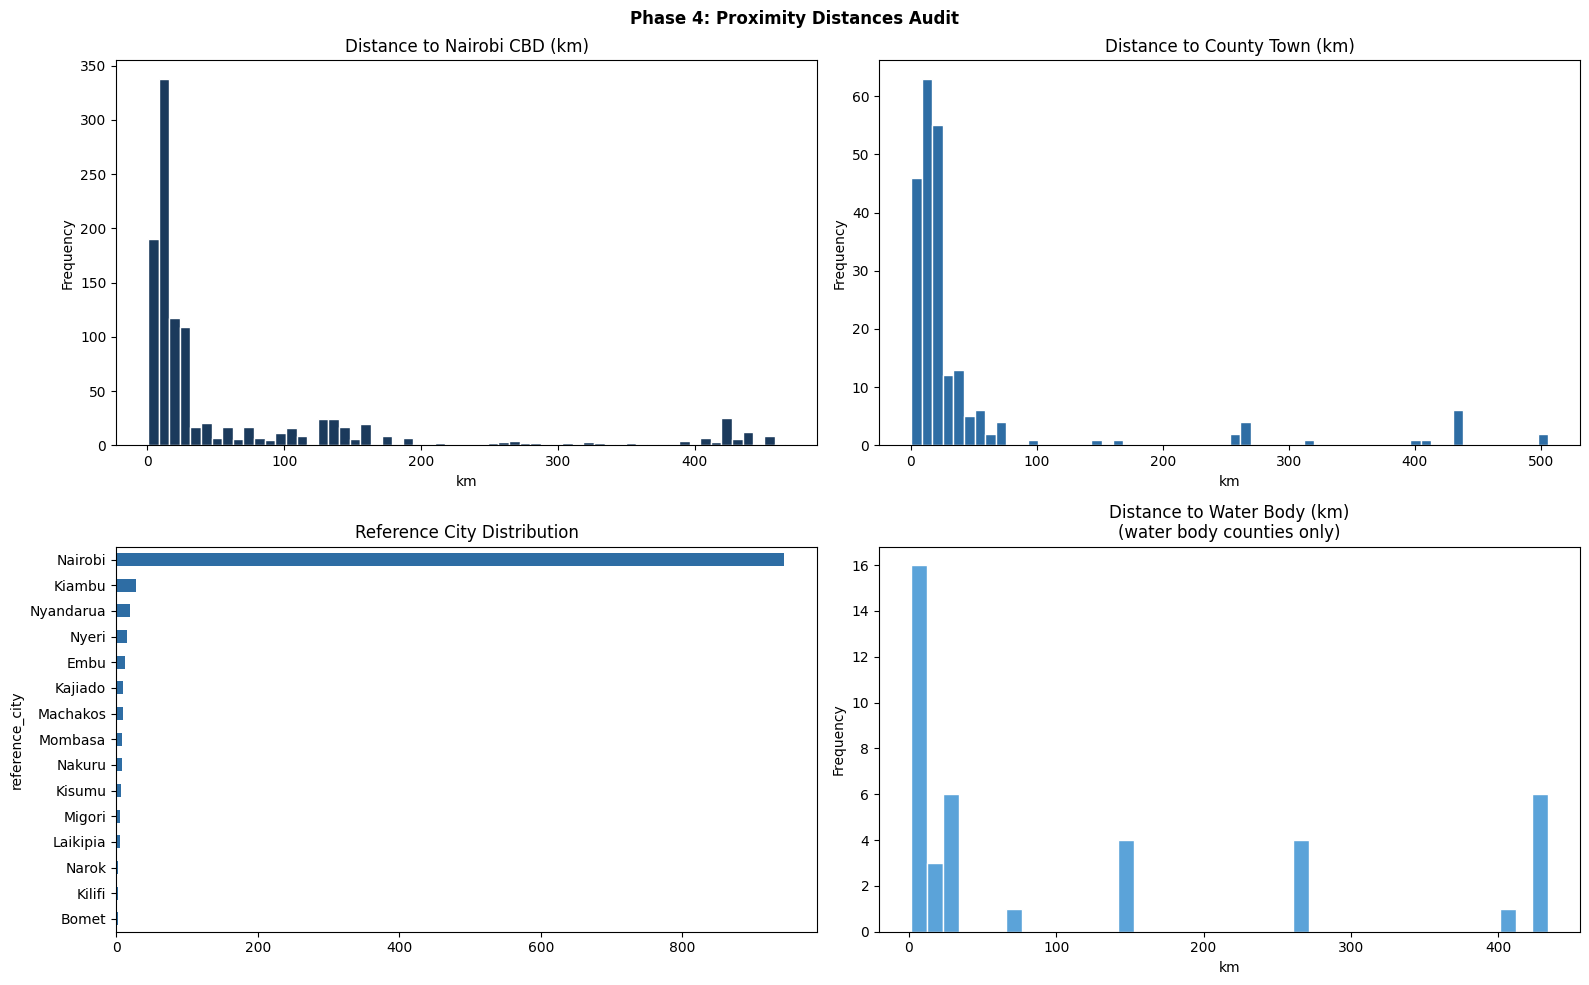

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Phase 4: Proximity Distances Audit", fontweight="bold")

df["dist_to_nairobi_km"].dropna().plot(
    kind="hist", bins=60, ax=axes[0, 0], color="#1B3A5C", edgecolor="white"
)
axes[0, 0].set_title("Distance to Nairobi CBD (km)")
axes[0, 0].set_xlabel("km")

df["dist_to_county_town_km"].dropna().plot(
    kind="hist", bins=60, ax=axes[0, 1], color="#2E6DA4", edgecolor="white"
)
axes[0, 1].set_title("Distance to County Town (km)")
axes[0, 1].set_xlabel("km")

df["reference_city"].value_counts().head(15).plot(
    kind="barh", ax=axes[1, 0], color="#2E6DA4"
)
axes[1, 0].set_title("Reference City Distribution")
axes[1, 0].invert_yaxis()

df["dist_to_water_body_km"].dropna().plot(
    kind="hist", bins=40, ax=axes[1, 1], color="#5BA3D9", edgecolor="white"
)
axes[1, 1].set_title("Distance to Water Body (km)\n(water body counties only)")
axes[1, 1].set_xlabel("km")

plt.tight_layout()
plt.show()

### Cell 4.7 — Phase 4 Summary & Save Checkpoint


In [ ]:
print("=" * 55)
print("PHASE 4 SUMMARY")
print("=" * 55)

cols = ["dist_to_nairobi_km", "dist_to_county_town_km",
        "reference_city_dist_km", "dist_to_water_body_km"]

summary = pd.DataFrame({
    "non_null": [df[c].notnull().sum() for c in cols],
    "null"    : [df[c].isnull().sum() for c in cols],
    "min"     : [round(df[c].min(), 2) for c in cols],
    "median"  : [round(df[c].median(), 2) for c in cols],
    "max"     : [round(df[c].max(), 2) for c in cols],
}, index=cols)
print(summary.to_string())

df.to_parquet(f"{INTERIM_DATA}/phase4_proximity.parquet", index=False)
print("\nCheckpoint saved: phase4_proximity.parquet")

PHASE 4 SUMMARY
                        non_null  null   min  median     max
dist_to_nairobi_km          1093     1  0.41   17.30  466.15
dist_to_county_town_km       226   868  0.00   19.42  505.93
reference_city_dist_km      1093     1  0.00   13.98  505.93
dist_to_water_body_km         41  1053  1.42   23.46  433.72

Checkpoint saved: phase4_proximity.parquet


---
## Phase 4B — County Assignment Correction

The simple string-match in Phase 4 left ~79% of records with a null county because the
`location` column stores neighbourhood names rather than county names. This phase corrects
that using a three-level waterfall:

1. **Spatial join** — match coordinates against the official Kenya county shapefile (most reliable)
2. **Town dictionary** — map known neighbourhood names to counties via a curated lookup table
3. **Nominatim API** — geocode any remaining unresolved town names and parse the county from the response

After county assignment, reference city distances are recalculated from scratch.


### Cell 4B.0 — Load Phase 4 Checkpoint


In [ ]:
import gc

df = pd.read_parquet(f"{INTERIM_DATA}/phase4_proximity.parquet")
print(f"Loaded  : {len(df):,} records")
print(f"county null before fix: {df['county'].isnull().sum():,}")

Loaded  : 1,094 records
county null before fix: 868


### Cell 4B.1 — Download Kenya County Shapefile

Downloads the GADM Level 1 county boundaries from UC Davis. Run this cell only once;
subsequent runs skip the download if the file already exists on Drive.


In [ ]:
import os, fiona

SHAPEFILE_PATH = f"{OSM_DATA}/kenya_counties.gpkg"

if not os.path.exists(SHAPEFILE_PATH):
    print("Downloading Kenya county boundaries...")
    os.system(
        f'wget -q --show-progress '
        f'"https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_KEN.gpkg" '
        f'-O {SHAPEFILE_PATH}'
    )
    print("Download complete.")
else:
    print("Shapefile already exists — skipping download.")

print(f"\nAvailable layers: {fiona.listlayers(SHAPEFILE_PATH)}")

Shapefile already exists — skipping download.

Available layers: ['ADM_ADM_0', 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3']


### Cell 4B.2 — Level 1: Spatial Join from Coordinates

Performs a point-in-polygon join between listing coordinates and the county boundary polygons.
This is the most accurate method and will resolve all records that have valid coordinates.


In [ ]:
print("Level 1: Spatial join from coordinates")

counties_gdf = gpd.read_file(SHAPEFILE_PATH, layer="ADM_ADM_1")
counties_gdf = (counties_gdf[["NAME_1", "geometry"]]
                .rename(columns={"NAME_1": "county_name"})
                .to_crs("EPSG:4326"))

print(f"County boundaries loaded: {len(counties_gdf)} counties")

has_coords = df["latitude"].notnull() & df["longitude"].notnull()
df_geo = gpd.GeoDataFrame(
    df[has_coords].copy(),
    geometry=gpd.points_from_xy(
        df.loc[has_coords, "longitude"],
        df.loc[has_coords, "latitude"]
    ),
    crs="EPSG:4326"
)

joined = gpd.sjoin(df_geo, counties_gdf, how="left", predicate="within")
df.loc[has_coords, "county_fixed"] = joined["county_name"].values

del df_geo, joined
gc.collect()

level1_resolved = df["county_fixed"].notnull().sum()
print(f"Level 1 resolved : {level1_resolved:,} records")
print(f"Still null       : {df['county_fixed'].isnull().sum():,} records")

Level 1: Spatial join from coordinates
County boundaries loaded: 47 counties
Level 1 resolved : 1,084 records
Still null       : 10 records


### Cell 4B.3 — Level 2: Town Name Dictionary Lookup

Maps neighbourhood and town names extracted from listing titles to their counties
using a curated dictionary covering ~130 locations found in this dataset.
Only runs on records not resolved by the spatial join.


In [ ]:
TOWN_TO_COUNTY = {
    # Nairobi
    "Nairobi CBD": "Nairobi",  "Westlands": "Nairobi",   "Karen": "Nairobi",
    "Lavington": "Nairobi",    "Runda": "Nairobi",        "Muthaiga": "Nairobi",
    "Gigiri": "Nairobi",       "Parklands": "Nairobi",    "Kilimani": "Nairobi",
    "Kileleshwa": "Nairobi",   "Loresho": "Nairobi",      "Rosslyn": "Nairobi",
    "Ridgeways": "Nairobi",    "Spring Valley": "Nairobi","Kyuna": "Nairobi",
    "Peponi": "Nairobi",       "Thigiri": "Nairobi",      "Nyari": "Nairobi",
    "Kitisuru": "Nairobi",     "New Kitisuru": "Nairobi", "Riverside": "Nairobi",
    "Mirema": "Nairobi",       "Garden Estate": "Nairobi","Kasarani": "Nairobi",
    "Eastleigh": "Nairobi",    "Embakasi": "Nairobi",     "Kawangware": "Nairobi",
    "Riruta": "Nairobi",       "Ruai": "Nairobi",         "Utawala": "Nairobi",
    "Thome": "Nairobi",
    # Kiambu
    "Kiambu": "Kiambu",        "Kiambu Road": "Kiambu",  "Ruiru": "Kiambu",
    "Thika": "Kiambu",         "Kikuyu": "Kiambu",        "Limuru": "Kiambu",
    "Tigoni": "Kiambu",        "Ndenderu": "Kiambu",      "Lower Kabete": "Kiambu",
    "Kinoo": "Kiambu",         "Redhill": "Kiambu",       "Thindigua": "Kiambu",
    "Githunguri": "Kiambu",    "Juja": "Kiambu",          "Tatu City": "Kiambu",
    "Mangu": "Kiambu",         "Ngong Rd": "Kiambu",
    # Kajiado
    "Ngong": "Kajiado",        "Ongata Rongai": "Kajiado","Kitengela": "Kajiado",
    "Isinya": "Kajiado",       "Kiserian": "Kajiado",     "Namanga": "Kajiado",
    "Kisaju": "Kajiado",       "Kerarapon": "Kajiado",    "Rongai": "Kajiado",
    # Machakos
    "Machakos": "Machakos",    "Athi River": "Machakos",  "Syokimau": "Machakos",
    "Katani": "Machakos",      "Joska": "Machakos",       "Lukenya": "Machakos",
    "Mua Hills": "Machakos",   "Konza": "Machakos",
    # Makueni
    "Kibwezi": "Makueni",      "Emali": "Makueni",        "Matuu": "Makueni",
    # Murang'a
    "Muranga": "Murang'a",     "Makuyu": "Murang'a",      "Kenol": "Murang'a",
    "Sagana": "Murang'a",
    # Kirinyaga
    "Kerugoya": "Kirinyaga",
    # Nyandarua
    "Nyandarua": "Nyandarua",  "Ol Kalou": "Nyandarua",   "Kinangop": "Nyandarua",
    # Nyeri
    "Nyeri": "Nyeri",          "Naro Moru": "Nyeri",
    # Laikipia
    "Laikipia": "Laikipia",    "Nanyuki": "Laikipia",     "Rumuruti": "Laikipia",
    "Timau": "Laikipia",       "Nyahururu": "Laikipia",
    # Nakuru
    "Nakuru East": "Nakuru",   "Njoro": "Nakuru",         "Naivasha": "Nakuru",
    "Gilgil": "Nakuru",        "Mai Mahiu": "Nakuru",     "Elementaita": "Nakuru",
    "Salgaa": "Nakuru",        "Subukia": "Nakuru",       "Bahati": "Nakuru",
    "Mau": "Nakuru",
    # Narok
    "Narok": "Narok",
    # Embu
    "Embu": "Embu",
    # Meru
    "Meru": "Meru",
    # Isiolo
    "Naka": "Isiolo",
    # Uasin Gishu
    "Eldoret South": "Uasin Gishu",
    # Trans Nzoia
    "Kitale Town": "Trans Nzoia",
    # Kisumu
    "Kisumu CBD": "Kisumu",    "Nyahera": "Kisumu",
    # Siaya
    "Siaya": "Siaya",
    # Migori
    "Migori": "Migori",
    # Kakamega
    "Kakamega": "Kakamega",
    # Kericho
    "Kericho": "Kericho",
    # Bomet
    "Bomet": "Bomet",
    # Busia
    "Busia": "Busia",
    # Mombasa
    "Mombasa CBD": "Mombasa",  "Mombasa Rd": "Mombasa",   "Nyali": "Mombasa",
    "Utange": "Mombasa",
    # Kilifi
    "Malindi": "Kilifi",       "Watamu": "Kilifi",        "Kilifi": "Kilifi",
    "Kikambala": "Kilifi",     "Vipingo": "Kilifi",       "Bofa Beach": "Kilifi",
    "Paga Beach": "Kilifi",
    # Kwale
    "Kwale": "Kwale",          "Diani": "Kwale",          "Shimba Hills": "Kwale",
    # Taita Taveta
    "Taveta": "Taita Taveta",  "Voi": "Taita Taveta",
    # Nandi
    "Konya": "Nandi",
    # Tharaka Nithi
    "Tuala": "Tharaka Nithi",
}

def extract_town_from_title(title):
    if pd.isnull(title):
        return None
    match = re.search(r'(?:in|at|near)\s+([A-Za-z][A-Za-z\s\-]+?)(?:\s*$)', str(title), re.I)
    return match.group(1).strip() if match else None

still_null = df["county_fixed"].isnull()
df.loc[still_null, "extracted_town"] = df.loc[still_null, "title"].apply(extract_town_from_title)
df.loc[still_null, "county_fixed"]   = df.loc[still_null, "extracted_town"].map(TOWN_TO_COUNTY)

level2_resolved = df["county_fixed"].notnull().sum() - level1_resolved
print(f"Level 2 resolved : {level2_resolved:,} additional records")
print(f"Still null       : {df['county_fixed'].isnull().sum():,} records")

unresolved_towns = df[df["county_fixed"].isnull()]["extracted_town"].value_counts()
if len(unresolved_towns) > 0:
    print(f"\nUnresolved towns proceeding to Level 3:")
    print(unresolved_towns.to_string())

Level 2 resolved : 9 additional records
Still null       : 1 records


### Cell 4B.4 — Level 3: Nominatim API for Remaining Towns

For any towns not covered by the dictionary, query Nominatim once per unique town name
and extract the county from the address components in the response. Each unique town is
queried only once regardless of how many listings reference it.


In [ ]:
print("Level 3: Nominatim API lookup")

KENYA_COUNTIES = set(COUNTY_TOWNS.keys())

still_null  = df["county_fixed"].isnull()
unresolved  = df.loc[still_null, "extracted_town"].dropna().unique()
print(f"Unique towns to resolve: {len(unresolved)}")

if len(unresolved) > 0:
    geolocator2 = Nominatim(user_agent="kenya_land_county_fix_v1", timeout=10)
    geocode2    = RateLimiter(geolocator2.geocode, min_delay_seconds=1.1)

    def get_county_from_nominatim(town):
        try:
            result = geocode2(f"{town}, Kenya")
            if not result:
                return None
            parts = [p.strip() for p in result.raw.get("display_name", "").split(",")]
            for part in parts:
                if part in KENYA_COUNTIES:
                    return part
        except Exception:
            pass
        return None

    api_cache = {}
    for i, town in enumerate(unresolved):
        county = get_county_from_nominatim(town)
        api_cache[town] = county
        print(f"  [{i+1}/{len(unresolved)}] {town:<25} -> {county or 'not found'}")

    df.loc[still_null, "county_fixed"] = df.loc[still_null, "extracted_town"].map(api_cache)

level3_resolved = df["county_fixed"].notnull().sum() - level1_resolved - level2_resolved
print(f"\nLevel 3 resolved : {level3_resolved:,} additional records")
print(f"Still null       : {df['county_fixed'].isnull().sum():,} records")

Level 3: Nominatim API lookup
Unique towns to resolve: 0

Level 3 resolved : 0 additional records
Still null       : 1 records


### Cell 4B.5 — Apply Fixed County and Recalculate Reference City

Replace the old county values with the corrected ones, then recompute all distance features
from scratch using the correct county assignments.


In [ ]:
print("Applying fixed county and recalculating proximity features...")

df["county"] = df["county_fixed"].combine_first(df["county"])
df = df.drop(columns=["county_fixed", "extracted_town"], errors="ignore")

print(f"county null after fix: {df['county'].isnull().sum():,}")
print(f"\nCounty distribution (top 20):")
print(df["county"].value_counts().head(20).to_string())

def get_reference_city_v2(row):
    county = row.get("county")
    lat, lon = row.get("latitude"), row.get("longitude")

    if pd.isnull(lat) or pd.isnull(lon) or pd.isnull(county):
        return np.nan, np.nan, np.nan

    town_coords  = COUNTY_TOWNS.get(county)
    dist_nairobi = haversine_km(lat, lon, *NAIROBI_CBD)
    dist_town    = haversine_km(lat, lon, *town_coords) if town_coords else np.nan

    if (county in NAIROBI_ADJACENT
            and pd.notnull(dist_town)
            and dist_nairobi < dist_town):
        return "Nairobi", round(dist_nairobi, 2), round(dist_town, 2)

    if pd.notnull(dist_town):
        return county, round(dist_town, 2), round(dist_nairobi, 2)

    return "Nairobi", round(dist_nairobi, 2), np.nan

results = df.apply(get_reference_city_v2, axis=1)
df["reference_city"]         = results.apply(lambda x: x[0])
df["reference_city_dist_km"] = results.apply(lambda x: x[1])
df["dist_to_county_town_km"] = results.apply(lambda x: x[2])

print(f"\nReference city distribution (top 20):")
print(df["reference_city"].value_counts().head(20).to_string())

malindi = df[df["title"].str.contains("Malindi", case=False, na=False)]
print(f"\nSanity check — Malindi records should reference Kilifi, not Nairobi:")
print(malindi[["title","county","reference_city","reference_city_dist_km"]].head(5).to_string())

Applying fixed county and recalculating proximity features...
county null after fix: 1

County distribution (top 20):
county
Nairobi      449
Kiambu       177
Kajiado      102
Machakos      87
Nakuru        53
Kilifi        46
Nyeri         28
Nyandarua     23
Murang'a      16
Laikipia      15
Meru          12
Mombasa       12
Embu          11
Kwale         10
Kirinyaga      7
Migori         6
Narok          5
Kisumu         5
Bomet          4
Baringo        4

Reference city distribution (top 20):
reference_city
Nairobi      682
Kiambu        97
Nakuru        53
Kilifi        45
Nyeri         28
Nyandarua     23
Kajiado       22
Murang'a      16
Laikipia      15
Machakos      15
Mombasa       12
Meru          12
Embu          11
Kwale         10
Kirinyaga      7
Migori         6
Narok          5
Kisumu         5
Makueni        4
Bomet          4

Sanity check — Malindi records should reference Kilifi, not Nairobi:
                       title  county reference_city  reference_city_dis

### Cell 4B.6 — Phase 4B Summary & Save Checkpoint


In [ ]:
print("=" * 55)
print("PHASE 4B SUMMARY")
print("=" * 55)
print(f"Total records            : {len(df):,}")
print(f"county resolved          : {df['county'].notnull().sum():,}")
print(f"county still null        : {df['county'].isnull().sum():,}")
print(f"\nResolution breakdown:")
print(f"  Level 1 (spatial join) : {level1_resolved:,}")
print(f"  Level 2 (dictionary)   : {level2_resolved:,}")
print(f"  Level 3 (API)          : {level3_resolved:,}")
print(f"\nNairobi as reference city: {(df['reference_city'] == 'Nairobi').sum():,}")

df.to_parquet(f"{INTERIM_DATA}/phase4b_county_fixed.parquet", index=False)
print(f"\nCheckpoint saved: phase4b_county_fixed.parquet")
print("Proceed to Part 2 of the notebook for Phases 5 onwards.")

PHASE 4B SUMMARY
Total records            : 1,094
county resolved          : 1,093
county still null        : 1

Resolution breakdown:
  Level 1 (spatial join) : 1,084
  Level 2 (dictionary)   : 9
  Level 3 (API)          : 0

Nairobi as reference city: 682

Checkpoint saved: phase4b_county_fixed.parquet
Proceed to Part 2 of the notebook for Phases 5 onwards.


# Kenya Land Valuation — Feature Engineering Pipeline (Part 2)

This is **Part 2** of the pipeline, covering:

- **Phase 5** — Amenities score (OSM proximity-based)
- **Phase 6** — Accessibility score (road network + city decay)
- **Phase 7** — Infrastructure score (NLP on descriptions)
- **Phase 8** — Derived columns and final dataset assembly
- **Phase 9** — Quality audit and sign-off

Each phase reads from the previous phase's parquet checkpoint, so you can resume any
phase without reprocessing earlier ones. Run cells in order within each phase.


---
## Phase 5 — Amenities Score

Measures proximity to seven amenity categories using OpenStreetMap POI data and a
gravity decay model: `score = weight * exp(-beta * distance_km)`.

A description-keyword floor prevents properties that mention an amenity in their text
from being penalised just because the OSM map is incomplete nearby.

**Cell execution order:**

| Cell | When to run |
|------|-------------|
| 5.A — Config and load | Every session |
| 5.B — Download .osm.pbf | Once only |
| 5.C — Extract POI GPKG | Once only |
| 5.D — Copy GPKG to local disk | Every session (fast, 1-2 min) |
| 5.E — Helper functions | Every session |
| 5.F — Per-amenity distance cache | Every session (skips cached amenities) |
| 5.G — Merge, score, save | Every session |


### Cell 5.A — Config and Load

Defines all amenity parameters, OSM tag filters, and description keyword patterns in one place. Loads the Phase 4B checkpoint and reports which amenities are already cached.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import gc, os, re, shutil
from sklearn.neighbors import BallTree

CACHE_DIR       = f"{INTERIM_DATA}/amenity_cache"
CHECKPOINT_IN   = f"{INTERIM_DATA}/phase4b_county_fixed.parquet"
CHECKPOINT_OUT  = f"{INTERIM_DATA}/phase5_amenities.parquet"
POIS_DRIVE      = f"{OSM_DATA}/kenya_pois.gpkg"
POIS_LOCAL      = "/content/kenya_pois.gpkg"
OSM_PBF         = f"{OSM_DATA}/kenya-latest.osm.pbf"
EARTH_RADIUS_KM = 6371.0

for d in [OSM_DATA, INTERIM_DATA, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

# Gravity model parameters: {amenity: (weight, beta)}
# weight = contribution to total score; beta = distance decay rate
AMENITY_PARAMS = {
    "hospital" : (0.25, 0.30),
    "school"   : (0.20, 0.40),
    "market"   : (0.20, 0.50),
    "bank"     : (0.15, 0.50),
    "police"   : (0.05, 0.30),
    "bus_stop" : (0.10, 0.80),
    "fuel"     : (0.05, 0.60),
}

# OSM tag filters for each amenity category
AMENITY_FILTERS = {
    "hospital" : {"amenity": ["hospital", "clinic", "dispensary", "health_centre", "health_center"]},
    "school"   : {"amenity": ["school", "university", "college", "kindergarten"]},
    "market"   : {"amenity": ["marketplace"], "shop": ["supermarket", "mall", "convenience"]},
    "bank"     : {"amenity": ["bank", "atm", "microfinance"]},
    "police"   : {"amenity": ["police"]},
    "bus_stop" : {"highway": ["bus_stop"], "amenity": ["bus_station"]},
    "fuel"     : {"amenity": ["fuel"]},
}

# Description keyword patterns used to apply score floors
DESCRIPTION_KEYWORDS = {
    "hospital" : re.compile(r"hospital|clinic|dispensary|health\s*cent", re.I),
    "school"   : re.compile(r"school|university|college|primary|secondary", re.I),
    "market"   : re.compile(r"market|supermarket|mall|shopping", re.I),
    "bank"     : re.compile(r"\bbank\b|atm|mpesa", re.I),
    "police"   : re.compile(r"police\s*station|police\s*post", re.I),
    "bus_stop" : re.compile(r"bus\s*stop|matatu|stage|terminus", re.I),
    "fuel"     : re.compile(r"petrol\s*station|fuel\s*station|filling\s*station", re.I),
}

df = pd.read_parquet(CHECKPOINT_IN)
print(f"Loaded  : {len(df):,} records")
print(f"RAM     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

cached    = [n for n in AMENITY_PARAMS if os.path.exists(f"{CACHE_DIR}/dist_{n}_km.parquet")]
remaining = [n for n in AMENITY_PARAMS if n not in cached]
print(f"\nCached   : {cached}")
print(f"Remaining: {remaining}")

Loaded  : 1,094 records
RAM     : 2.2 MB

Cached   : ['hospital', 'school', 'market', 'bank', 'police', 'bus_stop', 'fuel']
Remaining: []


### Cell 5.B — Download kenya-latest.osm.pbf

Downloads the full Kenya OSM extract from Geofabrik (~700 MB). Auto-skips if the file already exists on Drive. Run once per project.


In [ ]:
if not os.path.exists(OSM_PBF):
    print("Downloading kenya-latest.osm.pbf (~700 MB)...")
    os.system(
        f'wget -q --show-progress '
        f'"http://download.geofabrik.de/africa/kenya-latest.osm.pbf" '
        f'-O {OSM_PBF}'
    )
    print("Download complete.")
else:
    print("PBF already exists — skipping download.")

PBF already exists — skipping download.


### Cell 5.C — Extract kenya_pois.gpkg from PBF

Uses GDAL to filter only relevant OSM tags before loading into Python, keeping peak RAM manageable. Polygon area features are converted to centroids. Run once per project.


In [ ]:
if not os.path.exists(POIS_DRIVE):
    TEMP_OUT = "/content/kenya_temp.gpkg"
    os.system("apt install -qq gdal-bin > /dev/null")
    print("Extracting POIs via GDAL...")

    os.system(
        f'ogr2ogr -f "GPKG" {TEMP_OUT} {OSM_PBF} points '
        f'-where "amenity IS NOT NULL OR shop IS NOT NULL OR highway = \'bus_stop\'" '
        f'-select "amenity,shop,highway" '
        f'-lco SPATIAL_INDEX=YES -overwrite'
    )
    os.system(
        f'ogr2ogr -f "GPKG" -append {TEMP_OUT} {OSM_PBF} multipolygons '
        f'-where "amenity IS NOT NULL OR shop IS NOT NULL" '
        f'-select "amenity,shop" -nln multipolygons'
    )

    pts  = gpd.read_file(TEMP_OUT, layer="points")
    poly = gpd.read_file(TEMP_OUT, layer="multipolygons")
    print(f"Points: {len(pts):,} | Polygons: {len(poly):,}")

    poly["geometry"] = poly.geometry.centroid
    pois = pd.concat([pts, poly], ignore_index=True)
    del pts, poly
    gc.collect()

    tag_cols = [c for c in ["amenity", "shop", "highway"] if c in pois.columns]
    pois = (
        pois[pois.geometry.notnull()]
        .to_crs("EPSG:4326")
        .dropna(subset=tag_cols, how="all")
        .reset_index(drop=True)
    )

    pois.to_file(POIS_DRIVE, driver="GPKG")
    print(f"Saved {len(pois):,} POIs to {POIS_DRIVE}")
    del pois
    gc.collect()
    os.remove(TEMP_OUT)
else:
    print("kenya_pois.gpkg already exists — skipping extraction.")

kenya_pois.gpkg already exists — skipping extraction.


### Cell 5.D — Copy GPKG to Local Colab Disk

Google Drive reads at 10-50 MB/s; local Colab disk reads at ~500 MB/s. This one-time copy per session saves 2-4 minutes per amenity iteration.


In [ ]:
if not os.path.exists(POIS_LOCAL):
    print("Copying kenya_pois.gpkg to local disk (1-2 min)...")
    shutil.copy(POIS_DRIVE, POIS_LOCAL)
    print(f"Copied to {POIS_LOCAL}")
else:
    print("Local GPKG copy already exists — skipping.")

print(f"GPKG size: {os.path.getsize(POIS_LOCAL) / 1e6:.1f} MB")

Copying kenya_pois.gpkg to local disk (1-2 min)...
Copied to /content/kenya_pois.gpkg
GPKG size: 8.0 MB


### Cell 5.E — Helper Functions

- `load_pois` — reads the local GPKG, drops rows with no relevant tags
- `filter_pois` — selects rows matching a given amenity tag dictionary
- `build_tree` — builds a haversine BallTree from a filtered GeoDataFrame
- `calc_distances` — queries the tree for the nearest POI distance per listing


In [ ]:
def load_pois():
    """Load POIs from local disk. Called once per amenity iteration."""
    pois     = gpd.read_file(POIS_LOCAL, columns=["geometry", "amenity", "shop", "highway"])
    tag_cols = [c for c in ["amenity", "shop", "highway"] if c in pois.columns]
    pois     = (
        pois.dropna(subset=tag_cols, how="all")
            .loc[lambda d: d.geometry.notnull()]
            .reset_index(drop=True)
    )
    print(f"  POIs loaded : {len(pois):,} | RAM: {pois.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    return pois


def filter_pois(gdf, tag_filters):
    """Return rows from gdf that match any tag in tag_filters."""
    masks = [
        gdf[col].isin(values)
        for col, values in tag_filters.items()
        if col in gdf.columns
    ]
    if not masks:
        return gdf.iloc[0:0]
    combined = masks[0]
    for m in masks[1:]:
        combined = combined | m
    return gdf[combined].copy()


def build_tree(gdf):
    """Build a haversine BallTree from the geometry of a GeoDataFrame."""
    coords = np.radians(
        np.array([[g.y, g.x] for g in gdf.geometry if g is not None and not g.is_empty])
    )
    return BallTree(coords, metric="haversine") if len(coords) > 0 else None


def calc_distances(df, tree):
    """
    Query the BallTree for the nearest POI distance per listing.
    Returns a float32 Series in kilometres, NaN where coordinates are missing.
    """
    results    = pd.Series(np.nan, index=df.index, dtype=np.float32)
    valid_mask = df["latitude"].notnull() & df["longitude"].notnull()
    if tree is None or valid_mask.sum() == 0:
        return results
    coords  = np.radians(df.loc[valid_mask, ["latitude", "longitude"]].values)
    dist, _ = tree.query(coords, k=1)
    results.loc[valid_mask] = (dist.flatten() * EARTH_RADIUS_KM).astype(np.float32)
    return results.round(4)


print("Helper functions ready.")

Helper functions ready.


### Cell 5.F — Per-Amenity Distance Cache

For each amenity: load the full POI file, filter to relevant tags, build a BallTree, compute nearest-neighbour distances for all listings, save to a per-amenity parquet, then free all memory before the next amenity.

Already-cached amenities are skipped automatically. This cell is safe to re-run after a crash.

Expected runtime: approximately 10-20 minutes for all seven amenities.


In [ ]:
for name in AMENITY_PARAMS:
    cache_file = f"{CACHE_DIR}/dist_{name}_km.parquet"

    if os.path.exists(cache_file):
        print(f"  {name:<12}: cached — skipping")
        continue

    print(f"\n── {name.upper()} {'─' * (50 - len(name))}")

    pois     = load_pois()
    filtered = filter_pois(pois, AMENITY_FILTERS[name])
    count    = len(filtered)
    del pois
    gc.collect()

    print(f"  Filtered POIs: {count:,}")

    if count == 0:
        print(f"  WARNING: No POIs found for {name} — saving NaN column")
        result = pd.Series(np.nan, index=df.index, name=f"dist_{name}_km")
    else:
        tree   = build_tree(filtered)
        del filtered
        gc.collect()
        result = calc_distances(df, tree)
        result.name = f"dist_{name}_km"
        del tree
        gc.collect()

    result.to_frame().to_parquet(cache_file)
    print(f"  Saved | median = {result.median():.2f} km")
    del result
    gc.collect()

print("\nAll amenities processed.")

  hospital    : cached — skipping
  school      : cached — skipping
  market      : cached — skipping
  bank        : cached — skipping
  police      : cached — skipping
  bus_stop    : cached — skipping
  fuel        : cached — skipping

All amenities processed.


### Cell 5.G — Merge, Score, and Save

Reads all per-amenity cache files, applies the gravity model, applies description-keyword floors, sums to a final `amenities_score` (0-100), then drops the raw distance columns.


Merging distance columns...
  dist_hospital_km | median = 1.20 km
  dist_school_km | median = 0.40 km
  dist_market_km | median = 0.59 km
  dist_bank_km | median = 0.77 km
  dist_police_km | median = 1.40 km
  dist_bus_stop_km | median = 2.17 km
  dist_fuel_km | median = 0.72 km

Description floors applied: 542


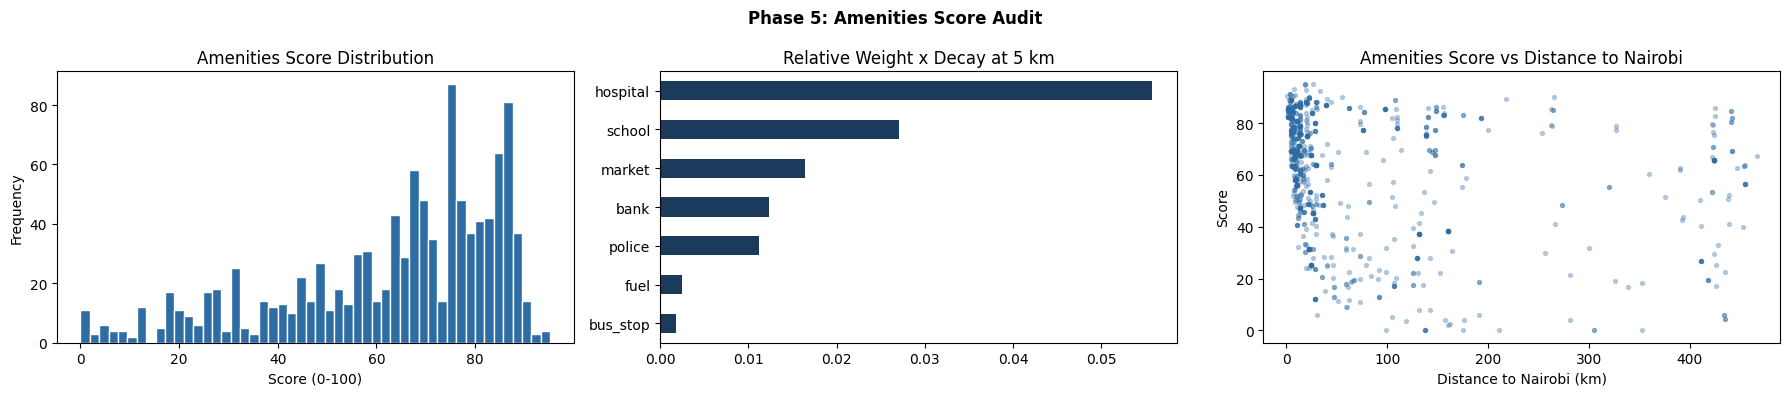

PHASE 5 SUMMARY
Total records         : 1,094
amenities_score valid : 1,094
amenities_score
0-20       66
20-40     117
40-60     192
60-80     428
80-100    286

Checkpoint saved: /content/drive/MyDrive/kenya_land_valuation/data/interim/phase5_amenities.parquet


In [ ]:
print("Merging distance columns...")
for name in AMENITY_PARAMS:
    cache_file = f"{CACHE_DIR}/dist_{name}_km.parquet"
    if os.path.exists(cache_file):
        df[f"dist_{name}_km"] = pd.read_parquet(cache_file).values
        print(f"  dist_{name}_km | median = {df[f'dist_{name}_km'].median():.2f} km")
    else:
        print(f"  WARNING: cache missing for {name}")
        df[f"dist_{name}_km"] = np.nan

# Gravity scores per amenity
raw_scores = pd.DataFrame(index=df.index)
for name, (weight, beta) in AMENITY_PARAMS.items():
    raw_scores[f"score_{name}"] = weight * np.exp(-beta * df[f"dist_{name}_km"])

# Description-keyword floors
# A listing that mentions an amenity cannot score below what 200m distance would give.
desc_lower     = df["description"].fillna("").str.lower()
floors_applied = 0
for name, pattern in DESCRIPTION_KEYWORDS.items():
    weight, beta = AMENITY_PARAMS[name]
    floor_score  = weight * np.exp(-beta * 0.2)
    score_col    = f"score_{name}"
    mention_mask = desc_lower.str.contains(pattern, regex=True)
    below_floor  = mention_mask & (raw_scores[score_col] < floor_score)
    raw_scores.loc[below_floor, score_col] = floor_score
    floors_applied += below_floor.sum()
del desc_lower
gc.collect()
print(f"\nDescription floors applied: {floors_applied:,}")

df["amenities_score"] = (raw_scores.sum(axis=1).clip(0, 1) * 100).round(2)
del raw_scores
df = df.drop(columns=[f"dist_{n}_km" for n in AMENITY_PARAMS if f"dist_{n}_km" in df.columns])
gc.collect()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Phase 5: Amenities Score Audit", fontweight="bold")

df["amenities_score"].plot(kind="hist", bins=50, ax=axes[0], color="#2E6DA4", edgecolor="white")
axes[0].set_title("Amenities Score Distribution")
axes[0].set_xlabel("Score (0-100)")

pd.Series({n: w * np.exp(-b * 5.0) for n, (w, b) in AMENITY_PARAMS.items()}).sort_values().plot(
    kind="barh", ax=axes[1], color="#1B3A5C")
axes[1].set_title("Relative Weight x Decay at 5 km")

axes[2].scatter(df["dist_to_nairobi_km"], df["amenities_score"], alpha=0.3, s=8, color="#2E6DA4")
axes[2].set_title("Amenities Score vs Distance to Nairobi")
axes[2].set_xlabel("Distance to Nairobi (km)")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

print("=" * 55)
print("PHASE 5 SUMMARY")
print("=" * 55)
print(f"Total records         : {len(df):,}")
print(f"amenities_score valid : {df['amenities_score'].notnull().sum():,}")
bins, labels = [0, 20, 40, 60, 80, 100], ["0-20", "20-40", "40-60", "60-80", "80-100"]
print(pd.cut(df["amenities_score"], bins=bins, labels=labels).value_counts().sort_index().to_string())

df.to_parquet(CHECKPOINT_OUT, index=False)
print(f"\nCheckpoint saved: {CHECKPOINT_OUT}")

---
## Phase 6 — Accessibility Score

Combines three decay signals into a single 0-100 score:

- **Road score (50%)** — gravity score from the nearest road, weighted by road class
- **Town score (30%)** — exponential decay from the reference city distance
- **Nairobi score (20%)** — exponential decay from distance to Nairobi CBD

**Cell 6.0** extracts the roads GPKG from the PBF. Run it once, then comment it out permanently.
If the session crashes after Cell 6.3, use the resume block to reload the road distance checkpoint.


### Cell 6.0 — Extract Roads from PBF (Run Once Only)

Extracts road line features from the OSM PBF using GDAL, excluding pedestrian infrastructure. Comment this cell out after the GPKG is saved to Drive.


In [ ]:
# ── RUN ONCE — comment out after GPKG is saved ───────────────

OSM_PBF    = f"{OSM_DATA}/kenya-latest.osm.pbf"
TEMP_OUT   = "/content/kenya_roads_temp.gpkg"
ROADS_PATH = f"{OSM_DATA}/kenya_roads.gpkg"

os.system("apt install -qq gdal-bin > /dev/null")
print("Extracting roads via GDAL...")

os.system(
    f'ogr2ogr -f "GPKG" {TEMP_OUT} {OSM_PBF} lines '
    f'-where "highway IS NOT NULL AND highway NOT IN '
    f"('footway','steps','cycleway','pedestrian','service')\" "
    f'-select "highway,name" -lco SPATIAL_INDEX=YES -overwrite'
)

roads = gpd.read_file(TEMP_OUT)
roads = (
    roads[roads["highway"].notnull()]
    .to_crs("EPSG:4326")[["geometry", "highway"]]
    .reset_index(drop=True)
)
roads.to_file(ROADS_PATH, driver="GPKG")
print(f"Saved {len(roads):,} road segments to {ROADS_PATH}")

del roads
gc.collect()
os.remove(TEMP_OUT)
print("Done. Comment out this cell now.")

Extracting roads via GDAL...
Saved 668,862 road segments to /content/drive/MyDrive/kenya_land_valuation/data/osm/kenya_roads.gpkg
Done. Comment out this cell now.


### Cell 6.A — Session Config and Load


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import gc, os, re
from sklearn.neighbors import BallTree

CHECKPOINT_IN   = f"{INTERIM_DATA}/phase5_amenities.parquet"
ROAD_CHECKPOINT = f"{INTERIM_DATA}/phase6_roads_checkpoint.parquet"
CHECKPOINT_OUT  = f"{INTERIM_DATA}/phase6_accessibility.parquet"
ROADS_PATH      = f"{OSM_DATA}/kenya_roads.gpkg"
EARTH_RADIUS_KM = 6371.0

ROAD_WEIGHTS = {
    "motorway"     : 1.00, "trunk"        : 0.85,
    "primary"      : 0.75, "secondary"    : 0.60,
    "tertiary"     : 0.40, "unclassified" : 0.20,
    "residential"  : 0.15, "track"        : 0.05,
    "path"         : 0.02,
}

SCORE_WEIGHTS = {"road": 0.50, "town": 0.30, "nairobi": 0.20}
ROAD_BETA     = 0.5
TOWN_BETA     = 0.08
NAIROBI_BETA  = 0.04

df = pd.read_parquet(CHECKPOINT_IN)
print(f"Loaded  : {len(df):,} records")
print(f"RAM     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded  : 1,094 records
RAM     : 2.2 MB


### Cell 6.1 — Load and Filter Roads


In [ ]:
print("Loading roads...")
roads = gpd.read_file(ROADS_PATH, columns=["geometry", "highway"])
roads = (
    roads[roads["highway"].notnull()]
    .loc[lambda d: d["highway"].isin(ROAD_WEIGHTS.keys())]
    .loc[lambda d: d.geometry.notnull()]
    .reset_index(drop=True)
)
print(f"Road segments : {len(roads):,}")
print(f"RAM           : {roads.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(roads["highway"].value_counts().to_string())

Loading roads...
Road segments : 666,642
RAM           : 43.8 MB
highway
residential     275118
path            146449
unclassified    131266
track            97880
tertiary          7297
secondary         3916
trunk             3366
primary           1289
motorway            61


### Cell 6.2 — Build One BallTree Per Road Type

Extracts all vertex coordinates from road line geometries and indexes them in a haversine BallTree. A separate tree is built per road type so road class can be used as a weight.


In [ ]:
def extract_line_coords(gdf):
    """Extract all vertex coordinates from a GeoDataFrame of line geometries."""
    coords = []
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        if geom.geom_type == "LineString":
            coords.extend(list(geom.coords))
        elif geom.geom_type == "MultiLineString":
            for line in geom.geoms:
                coords.extend(list(line.coords))
    return np.array(coords) if coords else None


def build_road_tree(gdf):
    """Build a haversine BallTree from road segment vertices."""
    coords = extract_line_coords(gdf)
    if coords is None or len(coords) == 0:
        return None
    # shapely returns (lon, lat) — flip to (lat, lon) for haversine
    return BallTree(np.radians(coords[:, [1, 0]]), metric="haversine")


road_trees = {}
for road_type in ROAD_WEIGHTS:
    subset = roads[roads["highway"] == road_type]
    if len(subset) == 0:
        road_trees[road_type] = None
        print(f"  {road_type:<15}: not in dataset")
        continue
    road_trees[road_type] = build_road_tree(subset)
    print(f"  {road_type:<15}: {len(subset):,} segments")

del roads
gc.collect()
print("Roads freed from memory.")

  motorway       : 61 segments
  trunk          : 3,366 segments
  primary        : 1,289 segments
  secondary      : 3,916 segments
  tertiary       : 7,297 segments
  unclassified   : 131,266 segments
  residential    : 275,118 segments
  track          : 97,880 segments
  path           : 146,449 segments
Roads freed from memory.


### Cell 6.3 — Calculate Road Distances and Save Checkpoint

Queries each BallTree for the nearest road vertex distance for all listings. Saves a mid-phase checkpoint immediately after so a session crash here does not require rebuilding the trees.


In [ ]:
def calc_road_distances(df, tree):
    """Nearest road distance in km per listing. NaN where coordinates are missing."""
    results    = pd.Series(np.nan, index=df.index, dtype=np.float32)
    valid_mask = df["latitude"].notnull() & df["longitude"].notnull()
    if tree is None or valid_mask.sum() == 0:
        return results
    coords  = np.radians(df.loc[valid_mask, ["latitude", "longitude"]].values)
    dist, _ = tree.query(coords, k=1)
    results.loc[valid_mask] = (dist.flatten() * EARTH_RADIUS_KM).astype(np.float32)
    return results.round(4)


print("Calculating road distances...")
for road_type, tree in road_trees.items():
    col        = f"dist_{road_type}_km"
    df[col]    = calc_road_distances(df, tree)
    median_str = f"{df[col].median():.2f} km" if df[col].notnull().sum() > 0 else "no data"
    print(f"  {col:<28}: {median_str}")

del road_trees
gc.collect()

df.to_parquet(ROAD_CHECKPOINT, index=False)
print(f"\nCheckpoint saved: {ROAD_CHECKPOINT}")

Calculating road distances...
  dist_motorway_km            : 12.52 km
  dist_trunk_km               : 1.44 km
  dist_primary_km             : 4.78 km
  dist_secondary_km           : 0.80 km
  dist_tertiary_km            : 0.59 km
  dist_unclassified_km        : 0.40 km
  dist_residential_km         : 0.05 km
  dist_track_km               : 0.97 km
  dist_path_km                : 0.56 km

Checkpoint saved: /content/drive/MyDrive/kenya_land_valuation/data/interim/phase6_roads_checkpoint.parquet


### Resume Block — Use if Session Crashed After Cell 6.3

Uncomment and run this block instead of re-running Cells 6.1-6.3.


In [ ]:
# df = pd.read_parquet(ROAD_CHECKPOINT)
# print(f"Resumed: {len(df):,} records | RAM: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

### Cell 6.4 — Road Score

For each listing, compute a gravity score per road type and keep the maximum. This gives each parcel credit for its best nearby road, not an average.


In [ ]:
print("Computing road scores...")

road_score_matrix = pd.DataFrame(index=df.index)
for road_type, weight in ROAD_WEIGHTS.items():
    col = f"dist_{road_type}_km"
    if col in df.columns:
        road_score_matrix[road_type] = weight * np.exp(-ROAD_BETA * df[col])

df["road_score_raw"] = road_score_matrix.max(axis=1).clip(0, 1)
del road_score_matrix
gc.collect()

print("road_score_raw stats:")
print(df["road_score_raw"].describe().round(4).to_string())

Computing road scores...
road_score_raw stats:
count    1093.0000
mean        0.6009
std         0.1982
min         0.0063
25%         0.4545
50%         0.5906
75%         0.7822
max         0.9919


### Cell 6.5 — Description Road Hints Floor

Properties that mention a road type in their description receive a minimum road score for that class at 500 m distance, preventing OSM road gaps from penalising well-described properties.


In [ ]:
ROAD_DESCRIPTION = {
    "highway_hint": (re.compile(r"highway|superhighway|dual\s*carriageway", re.I), 1.00),
    "tarmac_hint" : (re.compile(r"tarmac|tarmacked|all.weather", re.I),           0.75),
    "murram_hint" : (re.compile(r"murram|gravel\s*road|dirt\s*road", re.I),       0.20),
}

desc_lower = df["description"].fillna("").str.lower()

for hint_name, (pattern, weight_floor) in ROAD_DESCRIPTION.items():
    floor_score  = weight_floor * np.exp(-ROAD_BETA * 0.5)
    mention_mask = desc_lower.str.contains(pattern, regex=True)
    below_floor  = mention_mask & (df["road_score_raw"] < floor_score)
    df.loc[below_floor, "road_score_raw"] = floor_score
    print(f"  {hint_name:<18}: {mention_mask.sum():,} mentions | {below_floor.sum():,} floors applied")

del desc_lower
gc.collect()

  highway_hint      : 103 mentions | 71 floors applied
  tarmac_hint       : 310 mentions | 137 floors applied
  murram_hint       : 68 mentions | 0 floors applied


30

### Cell 6.6 — Town and Nairobi Decay Scores


In [ ]:
df["town_score_raw"]    = np.exp(-TOWN_BETA    * df["reference_city_dist_km"]).fillna(0)
df["nairobi_score_raw"] = np.exp(-NAIROBI_BETA * df["dist_to_nairobi_km"]).fillna(0)

print(f"town_score_raw    — mean: {df['town_score_raw'].mean():.3f}")
print(f"nairobi_score_raw — mean: {df['nairobi_score_raw'].mean():.3f}")

town_score_raw    — mean: 0.377
nairobi_score_raw — mean: 0.430


### Cell 6.7 — Final Accessibility Score and Cleanup

Combines the three component scores using the defined weights, clips to [0, 1], scales to 0-100, then drops all intermediate columns.


In [ ]:
raw_accessibility = (
    SCORE_WEIGHTS["road"]    * df["road_score_raw"]    +
    SCORE_WEIGHTS["town"]    * df["town_score_raw"]    +
    SCORE_WEIGHTS["nairobi"] * df["nairobi_score_raw"]
)

df["accessibility_score"] = (raw_accessibility.clip(0, 1) * 100).round(2)

drop_cols  = [f"dist_{t}_km" for t in ROAD_WEIGHTS]
drop_cols += ["road_score_raw", "town_score_raw", "nairobi_score_raw"]
df         = df.drop(columns=[c for c in drop_cols if c in df.columns])
gc.collect()

print("accessibility_score stats:")
print(df["accessibility_score"].describe().round(2).to_string())

accessibility_score stats:
count    1093.00
mean       51.88
std        15.24
min         0.31
25%        41.79
50%        51.97
75%        61.95
max        93.57


### Cell 6.8 — Visual Audit


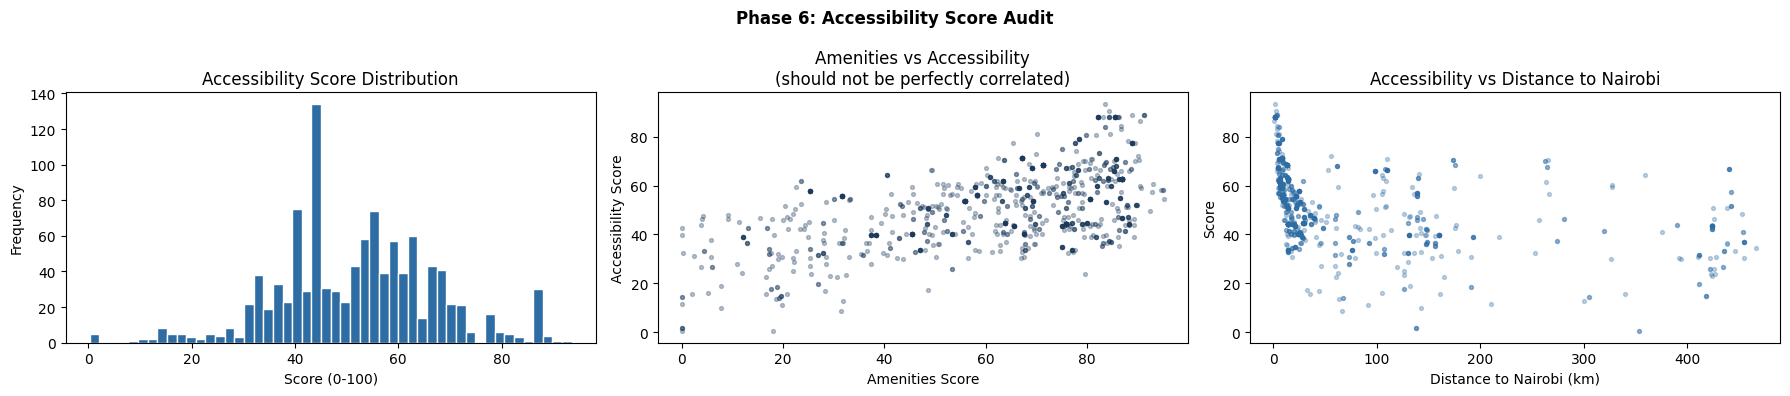

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Phase 6: Accessibility Score Audit", fontweight="bold")

df["accessibility_score"].plot(kind="hist", bins=50, ax=axes[0], color="#2E6DA4", edgecolor="white")
axes[0].set_title("Accessibility Score Distribution")
axes[0].set_xlabel("Score (0-100)")

axes[1].scatter(df["amenities_score"], df["accessibility_score"], alpha=0.3, s=8, color="#1B3A5C")
axes[1].set_title("Amenities vs Accessibility\n(should not be perfectly correlated)")
axes[1].set_xlabel("Amenities Score")
axes[1].set_ylabel("Accessibility Score")

axes[2].scatter(df["dist_to_nairobi_km"], df["accessibility_score"], alpha=0.3, s=8, color="#2E6DA4")
axes[2].set_title("Accessibility vs Distance to Nairobi")
axes[2].set_xlabel("Distance to Nairobi (km)")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

### Cell 6.9 — Phase 6 Summary and Save Checkpoint


In [ ]:
print("=" * 55)
print("PHASE 6 SUMMARY")
print("=" * 55)
print(f"Total records             : {len(df):,}")
print(f"accessibility_score valid : {df['accessibility_score'].notnull().sum():,}")

bins, labels = [0, 20, 40, 60, 80, 100], ["0-20", "20-40", "40-60", "60-80", "80-100"]
print("\nScore bands:")
print(pd.cut(df["accessibility_score"], bins=bins, labels=labels).value_counts().sort_index().to_string())

corr = df["accessibility_score"].corr(df["amenities_score"])
print(f"\nCorrelation with amenities_score : {corr:.3f}")
print("(target: < 0.85)")

df.to_parquet(CHECKPOINT_OUT, index=False)
print(f"\nCheckpoint saved: {CHECKPOINT_OUT}")

PHASE 6 SUMMARY
Total records             : 1,094
accessibility_score valid : 1,093

Score bands:
accessibility_score
0-20       31
20-40     187
40-60     562
60-80     268
80-100     45

Correlation with amenities_score : 0.560
(target: < 0.85)

Checkpoint saved: /content/drive/MyDrive/kenya_land_valuation/data/interim/phase6_accessibility.parquet


---
## Phase 7 — Infrastructure Score

Scores each listing on the physical infrastructure present on or adjacent to the land,
extracted from the free-text description using regex patterns. No OSM data is needed.

Categories: water supply, electricity, fencing, on-site structures, internal road quality.
Mutual exclusivity rules prevent double-counting. Records with descriptions too short for
reliable extraction receive the county median score as imputation.


### Cell 7.0 — Session Load


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc, re

CHECKPOINT_IN  = f"{INTERIM_DATA}/phase6_accessibility.parquet"
CHECKPOINT_OUT = f"{INTERIM_DATA}/phase7_infrastructure.parquet"

df = pd.read_parquet(CHECKPOINT_IN)
print(f"Loaded  : {len(df):,} records")
print(f"RAM     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded  : 1,094 records
RAM     : 2.2 MB


### Cell 7.1 — Infrastructure Keyword Dictionary

Each entry maps a feature to a `(regex, weight)` pair. Weights intentionally sum above 1.0 because no property will have every feature — the score is normalised by the theoretical maximum.


In [ ]:
INFRA_ITEMS = {
    # Water supply
    "borehole"      : (re.compile(r"borehole|bore\s*hole|drilled\s*well|solar.powered\s*borehole", re.I), 0.25),
    "piped_water"   : (re.compile(r"piped\s*water|nwsc|county\s*water|water\s*connect|mains\s*water", re.I), 0.20),
    "river_water"   : (re.compile(r"river\s*front|river\s*access|stream|spring\s*water", re.I), 0.10),
    "water_tank"    : (re.compile(r"water\s*tank|water\s*storage|rain\s*water", re.I), 0.07),
    # Electricity
    "grid_electric" : (re.compile(r"\bkplc\b|electricity|on.grid|power\s*connect|power\s*line\s*nearby", re.I), 0.22),
    "solar_electric": (re.compile(r"\bsolar\b|solar.powered|off.grid\s*solar|solar\s*panel", re.I), 0.08),
    # Fencing
    "full_fence"    : (re.compile(r"fenced\s*all\s*round|fully\s*fenced|perimeter\s*f|fenced\s*&\s*gated", re.I), 0.18),
    "partial_fence" : (re.compile(r"partially\s*fenced|fenced\s*on|fenced\s*on\s*(one|two|three)", re.I), 0.08),
    # Structures
    "structures"    : (re.compile(r"cow\s*shed|store|container|bungalow|house|site\s*office|farm\s*house|workers\s*quarter", re.I), 0.12),
    # Internal roads
    "internal_road" : (re.compile(r"cabro|tarmacked\s*entrance|murram\s*road\s*within|internal\s*road", re.I), 0.08),
}

MAX_INFRA_SCORE = sum(w for _, w in INFRA_ITEMS.values())
print(f"Infrastructure items      : {len(INFRA_ITEMS)}")
print(f"Max theoretical raw score : {MAX_INFRA_SCORE:.2f}")

Infrastructure items      : 10
Max theoretical raw score : 1.38


### Cell 7.2 — Extract Binary Feature Presence


In [ ]:
print("Extracting infrastructure features from descriptions...")

desc_lower = df["description"].fillna("").str.lower()

presence = pd.DataFrame(index=df.index)
for item, (pattern, _) in INFRA_ITEMS.items():
    presence[item] = desc_lower.str.contains(pattern, regex=True).astype(int)

del desc_lower
gc.collect()

print("Feature presence summary (total mentions):")
print(presence.sum().sort_values(ascending=False).to_string())

Extracting infrastructure features from descriptions...
Feature presence summary (total mentions):
structures        309
grid_electric     266
full_fence         73
internal_road      68
borehole           54
river_water        30
piped_water        27
solar_electric     25
water_tank         24
partial_fence       0


### Cell 7.3 — Mutual Exclusivity Rules

Prevents double-counting when two overlapping features are both detected. The stronger feature takes precedence.


In [ ]:
mask = (presence["full_fence"] == 1) & (presence["partial_fence"] == 1)
presence.loc[mask, "partial_fence"] = 0
print(f"Full + partial fence overlap fixed : {mask.sum()} records")

mask = (presence["borehole"] == 1) & (presence["water_tank"] == 1)
presence.loc[mask, "water_tank"] = 0
print(f"Borehole + tank overlap fixed      : {mask.sum()} records")

mask = (presence["grid_electric"] == 1) & (presence["solar_electric"] == 1)
presence.loc[mask, "solar_electric"] = 0
print(f"Grid + solar overlap fixed         : {mask.sum()} records")

Full + partial fence overlap fixed : 0 records
Borehole + tank overlap fixed      : 10 records
Grid + solar overlap fixed         : 4 records


### Cell 7.4 — Weighted Binary Score


In [ ]:
weights         = pd.Series({item: w for item, (_, w) in INFRA_ITEMS.items()})
raw_infra_score = presence.multiply(weights).sum(axis=1)

df["infrastructure_score"] = (raw_infra_score / MAX_INFRA_SCORE * 100).clip(0, 100).round(2)

print("infrastructure_score stats:")
print(df["infrastructure_score"].describe().round(2).to_string())

infrastructure_score stats:
count    1094.00
mean        9.19
std        10.59
min         0.00
25%         0.00
50%         8.70
75%        15.94
max        58.70


### Cell 7.5 — County Median Imputation

Records with descriptions shorter than 50 characters and a zero score receive the county median. A zero from a short description means no text to extract from, not no infrastructure present.


In [ ]:
short_desc_mask = df["description"].fillna("").str.len() < 50
zero_score_mask = df["infrastructure_score"] == 0
impute_mask     = short_desc_mask & zero_score_mask

print(f"Records with short/empty description : {short_desc_mask.sum():,}")
print(f"Records with zero infra score        : {zero_score_mask.sum():,}")
print(f"Records to impute (both conditions)  : {impute_mask.sum():,}")

county_medians = (
    df[~short_desc_mask]
    .groupby("county")["infrastructure_score"]
    .median()
    .round(2)
)
global_median = df.loc[~short_desc_mask, "infrastructure_score"].median()

print(f"\nCounty medians (top 15):")
print(county_medians.sort_values(ascending=False).head(15).to_string())
print(f"Global fallback median : {global_median:.2f}")

df["infra_source"] = "nlp_description"
df.loc[impute_mask, "infra_source"] = "imputed_county_median"

for idx in df[impute_mask].index:
    county = df.loc[idx, "county"]
    df.loc[idx, "infrastructure_score"] = county_medians.get(county, global_median)

print(f"\nImputation applied to {impute_mask.sum():,} records.")

Records with short/empty description : 74
Records with zero infra score        : 491
Records to impute (both conditions)  : 73

County medians (top 15):
county
Baringo       47.10
Makueni       36.96
Kwale         23.91
Lamu          15.94
Homa Bay      15.94
Migori        15.94
Nyandarua     15.94
Kajiado       15.94
Embu          14.49
Tana River    14.49
Nairobi        8.70
Murang'a       8.70
Nakuru         8.70
Machakos       8.70
Kiambu         8.70
Global fallback median : 8.70

Imputation applied to 73 records.


### Cell 7.6 — Feature Detection Audit

Checks detection rates per county for the top 10 counties. Presence columns are dropped after auditing and are not saved.


In [ ]:
top_counties = df["county"].value_counts().head(10).index
df_audit     = pd.concat([df[["county"]], presence], axis=1)
county_rates = (
    df_audit[df_audit["county"].isin(top_counties)]
    .groupby("county")[list(INFRA_ITEMS.keys())]
    .mean()
    .round(2)
)
print("Mean feature detection rate by county (top 10):")
print(county_rates.to_string())

del df_audit, presence
gc.collect()

Mean feature detection rate by county (top 10):
           borehole  piped_water  river_water  water_tank  grid_electric  solar_electric  full_fence  partial_fence  structures  internal_road
county                                                                                                                                        
Kajiado        0.12         0.03         0.00        0.00           0.42            0.03        0.17            0.0        0.12           0.02
Kiambu         0.04         0.02         0.02        0.00           0.34            0.00        0.04            0.0        0.36           0.05
Kilifi         0.02         0.09         0.09        0.09           0.13            0.04        0.07            0.0        0.09           0.04
Laikipia       0.07         0.00         0.13        0.00           0.27            0.00        0.00            0.0        0.20           0.00
Machakos       0.01         0.00         0.00        0.00           0.39            0.01      

0

### Cell 7.7 — Visual Audit


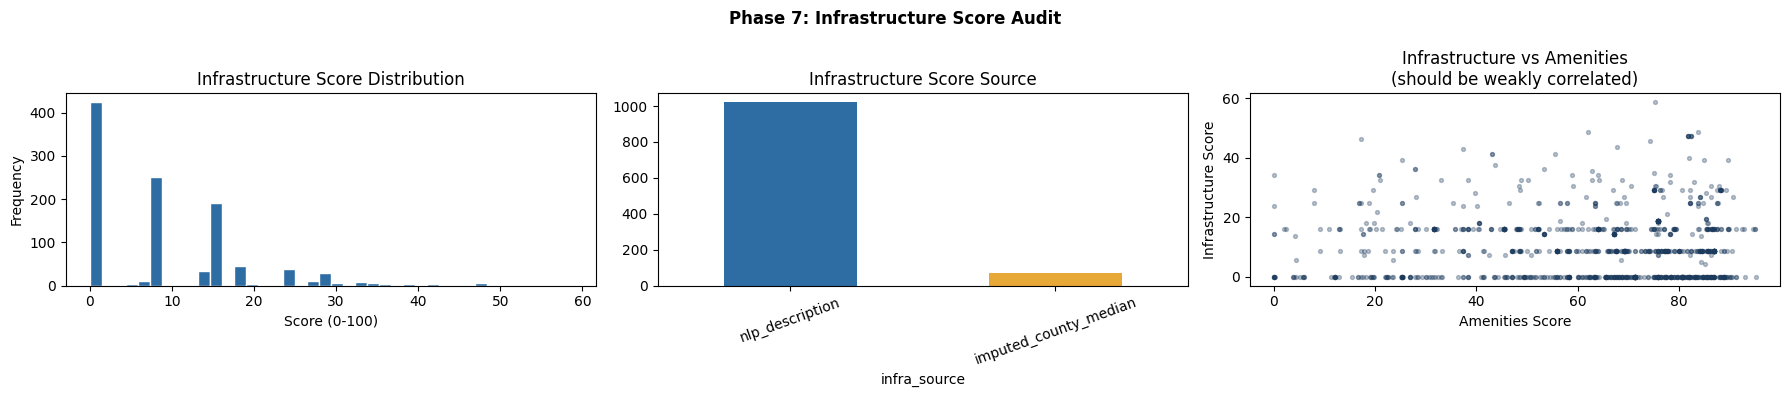

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Phase 7: Infrastructure Score Audit", fontweight="bold")

df["infrastructure_score"].plot(kind="hist", bins=40, ax=axes[0], color="#2E6DA4", edgecolor="white")
axes[0].set_title("Infrastructure Score Distribution")
axes[0].set_xlabel("Score (0-100)")

df["infra_source"].value_counts().plot(kind="bar", ax=axes[1], color=["#2E6DA4", "#E8A838"])
axes[1].set_title("Infrastructure Score Source")
axes[1].tick_params(axis="x", rotation=20)

axes[2].scatter(df["amenities_score"], df["infrastructure_score"], alpha=0.3, s=8, color="#1B3A5C")
axes[2].set_title("Infrastructure vs Amenities\n(should be weakly correlated)")
axes[2].set_xlabel("Amenities Score")
axes[2].set_ylabel("Infrastructure Score")

plt.tight_layout()
plt.show()

### Cell 7.8 — Phase 7 Summary and Save Checkpoint


In [ ]:
print("=" * 55)
print("PHASE 7 SUMMARY")
print("=" * 55)
print(f"Total records      : {len(df):,}")
print("\ninfra_source breakdown:")
print(df["infra_source"].value_counts().to_string())

bins, labels = [0, 20, 40, 60, 80, 100], ["0-20", "20-40", "40-60", "60-80", "80-100"]
print("\nScore bands:")
print(pd.cut(df["infrastructure_score"], bins=bins, labels=labels).value_counts().sort_index().to_string())

print(f"\nCorrelation with amenities_score    : {df['infrastructure_score'].corr(df['amenities_score']):.3f}")
print(f"Correlation with accessibility_score: {df['infrastructure_score'].corr(df['accessibility_score']):.3f}")
print("(both should be well below 0.85)")

df.to_parquet(CHECKPOINT_OUT, index=False)
print(f"\nCheckpoint saved: {CHECKPOINT_OUT}")

PHASE 7 SUMMARY
Total records      : 1,094

infra_source breakdown:
infra_source
nlp_description          1021
imputed_county_median      73

Score bands:
infrastructure_score
0-20      541
20-40     112
40-60      17
60-80       0
80-100      0

Correlation with amenities_score    : -0.009
Correlation with accessibility_score: -0.116
(both should be well below 0.85)

Checkpoint saved: /content/drive/MyDrive/kenya_land_valuation/data/interim/phase7_infrastructure.parquet


---
## Phase 8 — Derived Columns and Final Assembly

Computes the two target variables (`price_per_acre` and `log_price_per_acre`),
selects and orders the final column set, and saves both a parquet and a CSV copy.


### Cell 8.0 — Session Load


In [ ]:
import pandas as pd
import numpy as np
import gc

CHECKPOINT_IN  = f"{INTERIM_DATA}/phase7_infrastructure.parquet"
CHECKPOINT_OUT = f"{INTERIM_DATA}/kenya_land_engineered_final.parquet"

df = pd.read_parquet(CHECKPOINT_IN)
print(f"Loaded  : {len(df):,} records | RAM: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded  : 1,094 records | RAM: 2.3 MB


### Cell 8.1 — Derived Target Variables

`price_per_acre` is the primary modelling target. The log version is retained because land price distributions are right-skewed and the log form is closer to normal, which is better suited to MLP training.


In [ ]:
df["price_per_acre"] = (df["price_ksh"] / df["size_acres"]).round(2)

df["log_price_per_acre"] = np.where(
    df["price_per_acre"].notnull() & (df["price_per_acre"] > 0),
    np.log(df["price_per_acre"]),
    np.nan
)

print(f"price_per_acre valid     : {df['price_per_acre'].notnull().sum():,}")
print(f"log_price_per_acre valid : {df['log_price_per_acre'].notnull().sum():,}")

price_per_acre valid     : 817
log_price_per_acre valid : 817


### Cell 8.2 — Final Column Selection and Ordering

Only the columns listed here are kept. Everything else is dropped. The column order is documented so it is reproducible across runs.


In [ ]:
FINAL_COLUMNS = [
    # Identifiers (kept for traceability, not used as model features)
    "listing_url", "listing_no", "title", "location", "prop_type", "list_date",
    # Price
    "price_ksh", "price_flag", "log_price_ksh",
    # Size
    "size_acres", "size_source", "log_size_acres",
    # Coordinates
    "latitude", "longitude", "geocode_source", "geocode_confidence",
    # Proximity
    "county", "dist_to_nairobi_km", "dist_to_county_town_km",
    "dist_to_water_body_km", "reference_city", "reference_city_dist_km",
    # Pillar scores
    "amenities_score", "accessibility_score",
    "infrastructure_score", "infra_source",
    # Target variables
    "price_per_acre", "log_price_per_acre",
]

final_cols = [c for c in FINAL_COLUMNS if c in df.columns]
df         = df[final_cols]
gc.collect()

print(f"Final columns : {len(final_cols)}")
print(f"Final records : {len(df):,}")

Final columns : 28
Final records : 1,094


### Cell 8.3 — Final Summary and Save


In [ ]:
print("=" * 60)
print("PHASE 8 — FINAL DATASET SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    "dtype"   : df.dtypes.astype(str),
    "non_null": df.notnull().sum(),
    "null"    : df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(1),
})
print(summary.to_string())

print("\n--- Price per Acre (Target Variable) ---")
print(df["price_per_acre"].describe().apply(lambda x: f"KSh {x:,.0f}").to_string())

print("\n--- Three Pillar Scores ---")
for col in ["amenities_score", "accessibility_score", "infrastructure_score"]:
    print(f"{col:<25}: mean={df[col].mean():.1f}  median={df[col].median():.1f}  std={df[col].std():.1f}")

print("\n--- Score Correlations ---")
score_cols = ["amenities_score", "accessibility_score", "infrastructure_score", "log_price_per_acre"]
print(df[score_cols].corr().round(3).to_string())

df.to_parquet(CHECKPOINT_OUT, index=False)
df.to_csv(f"{RAW_DATA}/kenya_land_engineered_final.csv", index=False)
print(f"\nParquet saved : {CHECKPOINT_OUT}")
print(f"CSV saved     : kenya_land_engineered_final.csv")
print("Data engineering complete. Proceed to modelling.")

PHASE 8 — FINAL DATASET SUMMARY
                          dtype  non_null  null  null_pct
listing_url              object      1094     0       0.0
listing_no                int64      1094     0       0.0
title                    object      1094     0       0.0
location                 object      1094     0       0.0
prop_type                object      1094     0       0.0
list_date               float64         0  1094     100.0
price_ksh               float64      1019    75       6.9
price_flag               object      1094     0       0.0
log_price_ksh           float64      1019    75       6.9
size_acres              float64       821   273      25.0
size_source              object      1094     0       0.0
log_size_acres          float64       817   277      25.3
latitude                float64      1093     1       0.1
longitude               float64      1093     1       0.1
geocode_source           object      1094     0       0.0
geocode_confidence      float64      109

---
## Phase 9 — Quality Audit and Sign-Off

A structured checklist run against the final engineered dataset. All checks must pass
before the dataset is handed to the modelling notebook. Failures should be traced back
to the relevant phase and fixed there, not patched here.


### Cell 9.0 — Session Load


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

CHECKPOINT_IN = f"{INTERIM_DATA}/kenya_land_engineered_final.parquet"

df = pd.read_parquet(CHECKPOINT_IN)
print(f"Loaded  : {len(df):,} records | RAM: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded  : 1,094 records | RAM: 0.9 MB


### Cell 9.1 — Completeness Audit

Null counts and percentages for every column. Flags columns with more than 20% nulls.


In [ ]:
print("=" * 60)
print("COMPLETENESS AUDIT")
print("=" * 60)

summary = pd.DataFrame({
    "non_null" : df.notnull().sum(),
    "null"     : df.isnull().sum(),
    "null_pct" : (df.isnull().sum() / len(df) * 100).round(1),
    "dtype"    : df.dtypes.astype(str),
})
print(summary.to_string())

high_null = summary[summary["null_pct"] > 20]
if len(high_null) > 0:
    print(f"\nWARNING — Columns with >20% nulls:")
    print(high_null[["null_pct"]].to_string())
else:
    print("\nAll columns within acceptable null threshold.")

COMPLETENESS AUDIT
                        non_null  null  null_pct    dtype
listing_url                 1094     0       0.0   object
listing_no                  1094     0       0.0    int64
title                       1094     0       0.0   object
location                    1094     0       0.0   object
prop_type                   1094     0       0.0   object
list_date                      0  1094     100.0  float64
price_ksh                   1019    75       6.9  float64
price_flag                  1094     0       0.0   object
log_price_ksh               1019    75       6.9  float64
size_acres                   821   273      25.0  float64
size_source                 1094     0       0.0   object
log_size_acres               817   277      25.3  float64
latitude                    1093     1       0.1  float64
longitude                   1093     1       0.1  float64
geocode_source              1094     0       0.0   object
geocode_confidence          1094     0       0.0  flo

### Cell 9.2 — Coordinate Sanity Check


In [ ]:
print("=" * 60)
print("COORDINATE SANITY CHECK")
print("=" * 60)

KE_LAT = (-4.72, 4.62)
KE_LON = (33.91, 41.91)

valid_coords  = df["latitude"].notnull() & df["longitude"].notnull()
outside_kenya = valid_coords & (
    (df["latitude"]  < KE_LAT[0]) | (df["latitude"]  > KE_LAT[1]) |
    (df["longitude"] < KE_LON[0]) | (df["longitude"] > KE_LON[1])
)

print(f"Records with coordinates    : {valid_coords.sum():,}")
print(f"Records missing coordinates : {(~valid_coords).sum():,}")
print(f"Coordinates outside Kenya   : {outside_kenya.sum():,}")

if outside_kenya.sum() > 0:
    print("\nOutlier records:")
    print(df[outside_kenya][["listing_no", "location", "latitude", "longitude"]].to_string())

COORDINATE SANITY CHECK
Records with coordinates    : 1,093
Records missing coordinates : 1
Coordinates outside Kenya   : 0


### Cell 9.3 — Score Range Check

All three pillar scores must be within [0, 100].


In [ ]:
print("=" * 60)
print("SCORE RANGE CHECK (must be 0-100)")
print("=" * 60)

for col in ["amenities_score", "accessibility_score", "infrastructure_score"]:
    below = (df[col] < 0).sum()
    above = (df[col] > 100).sum()
    print(f"{col:<28}: min={df[col].min():.2f}  max={df[col].max():.2f}  below_0={below}  above_100={above}")

SCORE RANGE CHECK (must be 0-100)
amenities_score             : min=0.00  max=95.20  below_0=0  above_100=0
accessibility_score         : min=0.31  max=93.57  below_0=0  above_100=0
infrastructure_score        : min=0.00  max=58.70  below_0=0  above_100=0


### Cell 9.4 — Price per Acre and Size Outlier Check


In [ ]:
print("=" * 60)
print("PRICE PER ACRE OUTLIER CHECK")
print("=" * 60)

valid_ppa = df["price_per_acre"].dropna()
q01       = valid_ppa.quantile(0.01)
q99       = valid_ppa.quantile(0.99)
low_ppa   = df[df["price_per_acre"] < q01]
high_ppa  = df[df["price_per_acre"] > q99]

print(f"1st percentile  : KSh {q01:,.0f}")
print(f"99th percentile : KSh {q99:,.0f}")
print(f"Below 1st pct   : {len(low_ppa):,} records")
print(f"Above 99th pct  : {len(high_ppa):,} records")

if len(high_ppa) > 0:
    print("\nTop outliers (price_per_acre):")
    print(high_ppa[["listing_no", "location", "price_ksh", "size_acres", "price_per_acre"]].head(10).to_string())

print("\n" + "=" * 60)
print("SIZE OUTLIER CHECK")
print("=" * 60)
print(f"Below 0.05 acres   : {(df['size_acres'] < 0.05).sum():,}")
print(f"Above 50,000 acres : {(df['size_acres'] > 50_000).sum():,}")

PRICE PER ACRE OUTLIER CHECK
1st percentile  : KSh 3,083
99th percentile : KSh 545,454,545
Below 1st pct   : 9 records
Above 99th pct  : 8 records

Top outliers (price_per_acre):
      listing_no   location     price_ksh  size_acres  price_per_acre
24     116086491   Naivasha  1.600000e+09      0.0000             inf
296    116812667  Parklands  3.000000e+08      0.5000    6.000000e+08
307    116809611      Ruiru  2.400000e+07      0.0000             inf
336    116263128        Voi  1.750000e+09      0.0000             inf
423    116863796  Westlands  5.300000e+08      0.8826    6.004985e+08
441    116788431  Westlands  5.500000e+08      1.0000    5.500000e+08
524    116841831  Westlands  2.400000e+08      0.4000    6.000000e+08
1079   114049215    Kericho  4.500000e+06      0.0000             inf

SIZE OUTLIER CHECK
Below 0.05 acres   : 5
Above 50,000 acres : 0


### Cell 9.5 — Geocode Confidence Distribution


In [ ]:
print("=" * 60)
print("GEOCODE CONFIDENCE")
print("=" * 60)

print(df["geocode_source"].value_counts().to_string())
print(f"\nMean confidence                : {df['geocode_confidence'].mean():.3f}")
print(f"Low confidence records (< 0.3) : {(df['geocode_confidence'] < 0.3).sum():,}")

GEOCODE CONFIDENCE
geocode_source
street_address     747
nlp_landmark       232
location_town      112
county_centroid      2
failed               1

Mean confidence                : 0.683
Low confidence records (< 0.3) : 3


### Cell 9.6 — Correlation Matrix

High correlation between an input feature and the target is expected and desirable. High correlation between two input features flags potential redundancy.


In [ ]:
print("=" * 60)
print("SCORE CORRELATION MATRIX")
print("=" * 60)

score_cols = [c for c in [
    "amenities_score", "accessibility_score", "infrastructure_score",
    "log_price_per_acre", "log_size_acres", "dist_to_nairobi_km"
] if c in df.columns]

corr = df[score_cols].corr().round(3)
print(corr.to_string())

high_corr = [
    (score_cols[i], score_cols[j], abs(corr.iloc[i, j]))
    for i in range(len(score_cols))
    for j in range(i + 1, len(score_cols))
    if abs(corr.iloc[i, j]) > 0.85
]

if high_corr:
    print("\nWARNING — High correlations (> 0.85):")
    for a, b, v in high_corr:
        print(f"  {a} vs {b} : {v:.3f}")
else:
    print("\nNo problematic correlations detected.")

SCORE CORRELATION MATRIX
                      amenities_score  accessibility_score  infrastructure_score  log_price_per_acre  log_size_acres  dist_to_nairobi_km
amenities_score                 1.000                0.560                -0.009               0.262          -0.183              -0.253
accessibility_score             0.560                1.000                -0.116               0.280          -0.119              -0.391
infrastructure_score           -0.009               -0.116                 1.000              -0.057          -0.060               0.015
log_price_per_acre              0.262                0.280                -0.057               1.000          -0.670              -0.342
log_size_acres                 -0.183               -0.119                -0.060              -0.670           1.000               0.144
dist_to_nairobi_km             -0.253               -0.391                 0.015              -0.342           0.144               1.000

No problematic 

### Cell 9.7 — Visual Audit


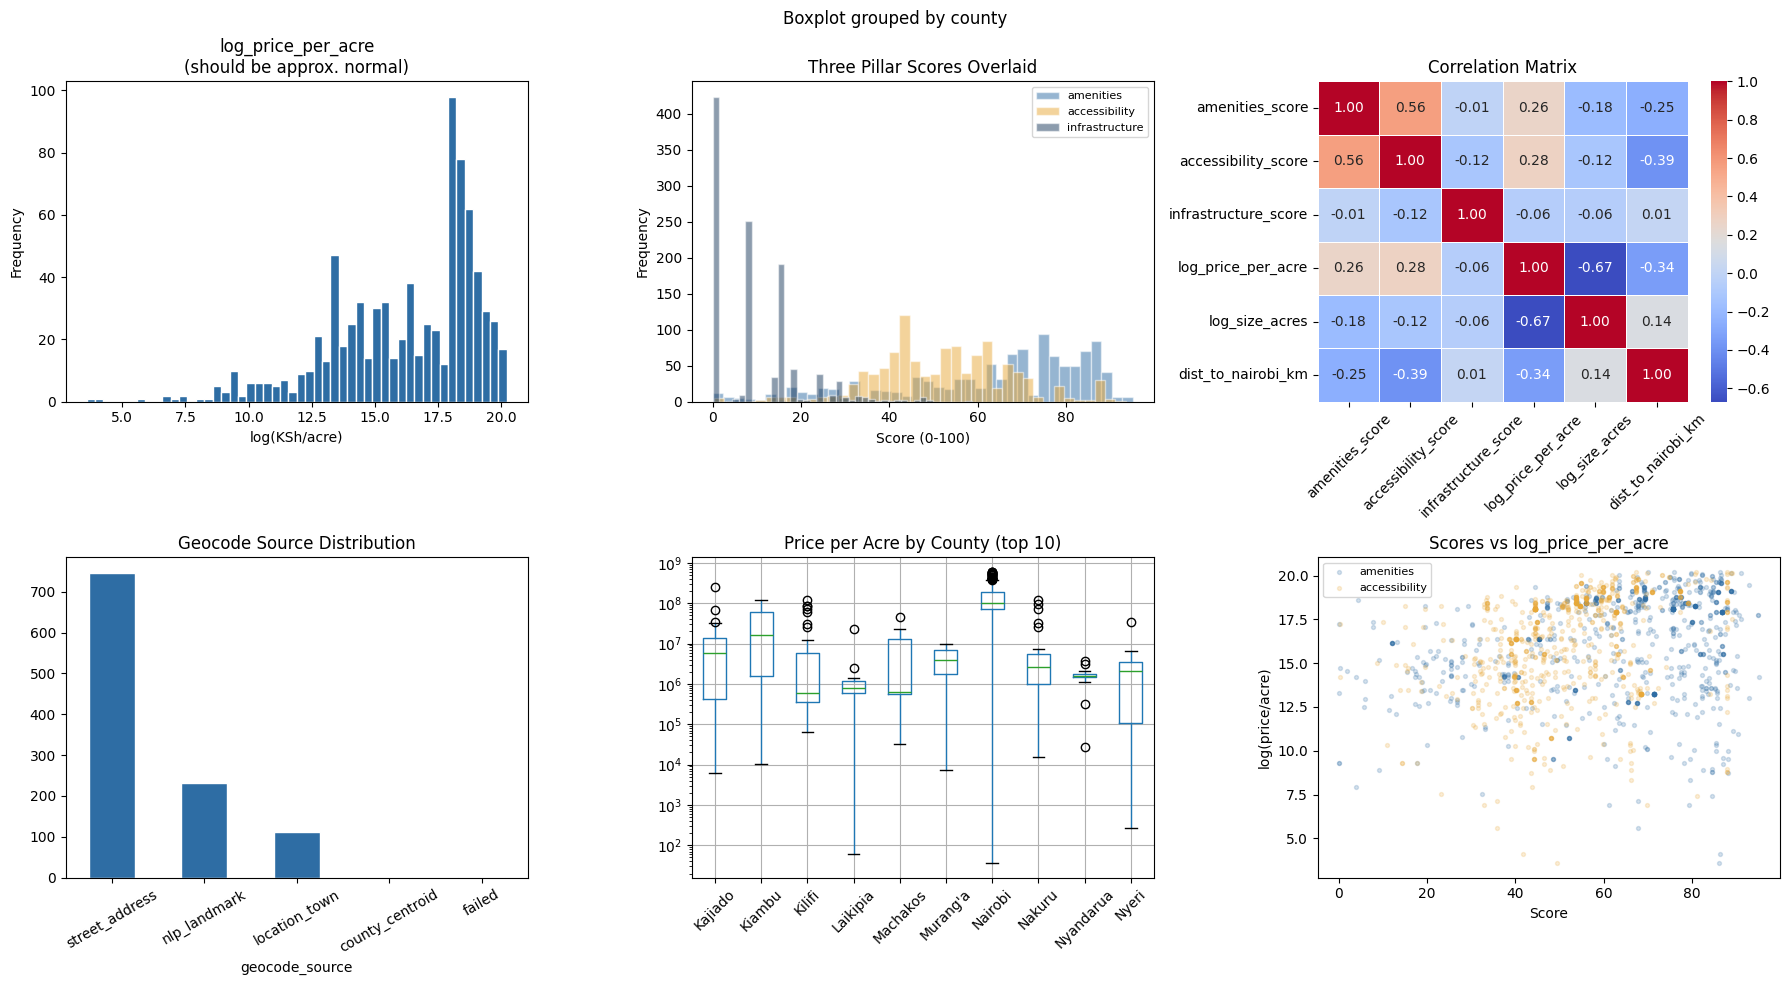

Chart saved to outputs folder.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Phase 9: Final Quality Audit", fontweight="bold")

df["log_price_per_acre"].replace([np.inf, -np.inf], np.nan).dropna().plot(
    kind="hist", bins=50, ax=axes[0, 0], color="#2E6DA4", edgecolor="white"
)
axes[0, 0].set_title("log_price_per_acre\n(should be approx. normal)")
axes[0, 0].set_xlabel("log(KSh/acre)")

for col, color in zip(
    ["amenities_score", "accessibility_score", "infrastructure_score"],
    ["#2E6DA4", "#E8A838", "#1B3A5C"]
):
    df[col].plot(kind="hist", bins=40, ax=axes[0, 1],
                 alpha=0.5, color=color, label=col.split("_")[0], edgecolor="white")
axes[0, 1].set_title("Three Pillar Scores Overlaid")
axes[0, 1].set_xlabel("Score (0-100)")
axes[0, 1].legend(fontsize=8)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[0, 2], cbar=True, linewidths=0.5)
axes[0, 2].set_title("Correlation Matrix")
axes[0, 2].tick_params(axis="x", rotation=45)

df["geocode_source"].value_counts().plot(
    kind="bar", ax=axes[1, 0], color="#2E6DA4", edgecolor="white"
)
axes[1, 0].set_title("Geocode Source Distribution")
axes[1, 0].tick_params(axis="x", rotation=30)

top_counties = df["county"].value_counts().head(10).index
df[df["county"].isin(top_counties)].boxplot(
    column="price_per_acre", by="county", ax=axes[1, 1]
)
axes[1, 1].set_title("Price per Acre by County (top 10)")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].set_yscale("log")
plt.sca(axes[1, 1])

log_ppa = df["log_price_per_acre"].replace([np.inf, -np.inf], np.nan)
axes[1, 2].scatter(df["amenities_score"],     log_ppa, alpha=0.2, s=8, color="#2E6DA4", label="amenities")
axes[1, 2].scatter(df["accessibility_score"], log_ppa, alpha=0.2, s=8, color="#E8A838", label="accessibility")
axes[1, 2].set_title("Scores vs log_price_per_acre")
axes[1, 2].set_xlabel("Score")
axes[1, 2].set_ylabel("log(price/acre)")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/phase9_quality_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs folder.")

### Cell 9.8 — Final Sign-Off Checklist

Five automated checks. All must pass before handing the dataset to the modelling notebook.


In [ ]:
print("=" * 60)
print("PHASE 9 — FINAL SIGN-OFF")
print("=" * 60)
print(f"Total records              : {len(df):,}")
print(f"Records with target var    : {df['log_price_per_acre'].notnull().sum():,}")
print(f"Records without target var : {df['log_price_per_acre'].isnull().sum():,}")
print(f"Total engineered columns   : {len(df.columns)}")
print(f"Final RAM                  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

score_cols_check = ["amenities_score", "accessibility_score", "infrastructure_score"]

checks = {
    "No coordinates outside Kenya" : outside_kenya.sum() == 0,
    "All scores in 0-100 range"    : all(
        (df[c].min() >= 0) and (df[c].max() <= 100) for c in score_cols_check
    ),
    "No problematic correlations"  : len(high_corr) == 0,
    "Target variable >50% filled"  : df["log_price_per_acre"].notnull().mean() > 0.50,
    "Geocode confidence mean > 0.4": df["geocode_confidence"].mean() > 0.40,
}

print("\nChecklist:")
all_passed = True
for check, passed in checks.items():
    status     = "PASS" if passed else "FAIL"
    all_passed = all_passed and passed
    print(f"  [{status}] {check}")

if all_passed:
    print("\nDATA ENGINEERING COMPLETE — READY FOR MODELLING")
else:
    print("\nREVIEW FAILED CHECKS BEFORE PROCEEDING")

PHASE 9 — FINAL SIGN-OFF
Total records              : 1,094
Records with target var    : 817
Records without target var : 277
Total engineered columns   : 28
Final RAM                  : 0.9 MB

Checklist:
  [PASS] No coordinates outside Kenya
  [PASS] All scores in 0-100 range
  [PASS] No problematic correlations
  [PASS] Target variable >50% filled
  [PASS] Geocode confidence mean > 0.4

DATA ENGINEERING COMPLETE — READY FOR MODELLING


# Kenya Land Valuation — MLP Model

This notebook trains a Multi-Layer Perceptron (MLP) to predict `log(price per acre)`
for Kenyan land listings. It reads directly from the final engineered dataset produced
by Part 2 of the pipeline (`kenya_land_engineered_final.parquet`).

**Cell order — run each cell separately, in sequence:**

| Cell | Purpose |
|------|---------|
| M0 — Session setup | Install packages, imports, paths |
| M1 — Load and inspect data | Load parquet, validate target |
| M2 — Feature selection | Define which columns enter the model |
| M3 — Train / val / test split | 70 / 15 / 15 stratified split |
| M4 — Scale features | Fit StandardScaler on train only |
| M5 — OLS baseline | Linear regression reference point |
| M6 — MLP architecture | Define the network class |
| M7 — Training loop | Train with early stopping |
| M8 — Evaluate on test set | Metrics + residual analysis |
| M9 — Visual audit | Prediction charts |
| M10 — Save model | Persist weights and scaler |


## Cell M0 — Session Setup

Installs PyTorch (already present on Colab GPU runtimes), mounts Drive, and sets
global plot style and colour constants used throughout the notebook.
Run this every time a new session starts.


In [24]:
from google.colab import drive
drive.mount("/content/drive")

import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset+

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

# Project paths — same structure as the pipeline notebooks
PROJECT_ROOT = "/content/drive/MyDrive/kenya_land_valuation"
INTERIM_DATA = f"{PROJECT_ROOT}/data/interim"
MODEL_DIR    = f"{PROJECT_ROOT}/models"
OUTPUTS      = f"{PROJECT_ROOT}/outputs/modelling"

for d in [MODEL_DIR, OUTPUTS]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

# Consistent colour palette
BLUE   = "#2E6DA4"
ORANGE = "#E8A838"
DARK   = "#1B3A5C"
RED    = "#D9534F"

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "sans-serif",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
})

print("Session setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cpu
Session setup complete.


## Cell M1 — Load and Inspect Data

Loads the final engineered parquet from Phase 8. Drops records where the target
variable is missing, zero, or infinite — these cannot be used for regression.
Prints a summary so you can confirm the dataset shape before proceeding.


In [25]:
DATA_PATH = f"{INTERIM_DATA}/kenya_land_engineered_final.parquet"

df_raw = pd.read_parquet(DATA_PATH)
print(f"Raw records loaded : {len(df_raw):,}")
print(f"Columns            : {list(df_raw.columns)}")

TARGET = "log_price_per_acre"

# Remove records that cannot be used for regression
df_raw = df_raw[df_raw["size_acres"]     > 0].copy()
df_raw = df_raw[df_raw["price_per_acre"] > 0].copy()
df_raw = df_raw[np.isfinite(df_raw[TARGET])].copy()
df_raw = df_raw.reset_index(drop=True)

print(f"\nRecords after cleaning : {len(df_raw):,}")
print(f"Records removed        : {len(pd.read_parquet(DATA_PATH)) - len(df_raw):,}")

print(f"\nTarget variable ({TARGET}):")
print(f"  Min    : {df_raw[TARGET].min():.4f}")
print(f"  Max    : {df_raw[TARGET].max():.4f}")
print(f"  Mean   : {df_raw[TARGET].mean():.4f}")
print(f"  Median : {df_raw[TARGET].median():.4f}")
print(f"  Std    : {df_raw[TARGET].std():.4f}")

Raw records loaded : 1,094
Columns            : ['listing_url', 'listing_no', 'title', 'location', 'prop_type', 'list_date', 'price_ksh', 'price_flag', 'log_price_ksh', 'size_acres', 'size_source', 'log_size_acres', 'latitude', 'longitude', 'geocode_source', 'geocode_confidence', 'county', 'dist_to_nairobi_km', 'dist_to_county_town_km', 'dist_to_water_body_km', 'reference_city', 'reference_city_dist_km', 'amenities_score', 'accessibility_score', 'infrastructure_score', 'infra_source', 'price_per_acre', 'log_price_per_acre']

Records after cleaning : 813
Records removed        : 281

Target variable (log_price_per_acre):
  Min    : 3.5951
  Max    : 20.2133
  Mean   : 16.1720
  Median : 16.9510
  Std    : 2.8765


## Cell M2 — Feature Selection

Defines which engineered columns enter the MLP as inputs. All features listed here
were produced by the pipeline: Phases 1-2 (price/size), Phase 3 (geocoding),
Phase 4 (proximity), and Phases 5-7 (pillar scores).

Edit `MLP_FEATURES` here if you want to experiment with different subsets.
The cell also drops any rows that are missing one or more of the required features,
and reports the null count per column before dropping so you can trace gaps back to
the relevant pipeline phase.


In [26]:
MLP_FEATURES = [
    # Size
    "log_size_acres",
    # Proximity
    "dist_to_nairobi_km",
    "dist_to_county_town_km",
    "dist_to_water_body_km",
    "reference_city_dist_km",
    # Geocode quality
    "geocode_confidence",
    # Pillar scores (Phases 5-7)
    "amenities_score",
    "accessibility_score",
    "infrastructure_score",
]

# Check nulls before dropping
required_cols = MLP_FEATURES + [TARGET]
null_counts   = df_raw[required_cols].isnull().sum()
print("Null counts per required column:")
print(null_counts.to_string())

df = df_raw[required_cols].dropna().reset_index(drop=True)

print(f"\nRecords available for modelling : {len(df):,}")
print(f"Records dropped (any null)      : {len(df_raw) - len(df):,}")
print(f"\nFeature count : {len(MLP_FEATURES)}")
print(f"Features      : {MLP_FEATURES}")

Null counts per required column:
log_size_acres              0
dist_to_nairobi_km          0
dist_to_county_town_km      1
dist_to_water_body_km     781
reference_city_dist_km      0
geocode_confidence          0
amenities_score             0
accessibility_score         0
infrastructure_score        0
log_price_per_acre          0

Records available for modelling : 32
Records dropped (any null)      : 781

Feature count : 9
Features      : ['log_size_acres', 'dist_to_nairobi_km', 'dist_to_county_town_km', 'dist_to_water_body_km', 'reference_city_dist_km', 'geocode_confidence', 'amenities_score', 'accessibility_score', 'infrastructure_score']


## Cell M3 — Train / Val / Test Split

Splits the data into three non-overlapping sets:

- **Train (70%)** — used to update model weights
- **Validation (15%)** — used for early stopping and hyperparameter decisions
- **Test (15%)** — held out until final evaluation; never seen during training

The random seed is fixed so the split is reproducible across runs.


In [27]:
X = df[MLP_FEATURES].values
y = df[TARGET].values

# First split: hold out 15% as the test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Second split: from remaining 85%, hold out ~15% of total as validation
# 0.15 / 0.85 = 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=42
)

print(f"Train set  : {len(X_train):,} records  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val set    : {len(X_val):,}   records  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set   : {len(X_test):,}  records  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTarget range in each split:")
print(f"  Train : {y_train.min():.3f} to {y_train.max():.3f}")
print(f"  Val   : {y_val.min():.3f} to {y_val.max():.3f}")
print(f"  Test  : {y_test.min():.3f} to {y_test.max():.3f}")

Train set  : 22 records  (68.8%)
Val set    : 5   records  (15.6%)
Test set   : 5  records  (15.6%)

Target range in each split:
  Train : 11.448 to 19.966
  Val   : 6.908 to 19.636
  Test  : 13.528 to 19.966


## Cell M4 — Scale Features

MLP training is sensitive to feature magnitude. StandardScaler centres each feature
to zero mean and unit variance using statistics computed on the training set only.
The same fitted scaler is then applied to val and test — never refit on them.
This prevents data leakage from the test set into the scaling step.

The fitted scaler is saved in Cell M10 alongside the model weights so it can be
applied identically at inference time.


In [28]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_val_sc   = scaler.transform(X_val)         # transform only
X_test_sc  = scaler.transform(X_test)        # transform only

print("Feature scaling applied.")
print(f"\nScaler mean (first 5 features)  : {scaler.mean_[:5].round(4)}")
print(f"Scaler scale (first 5 features) : {scaler.scale_[:5].round(4)}")

Feature scaling applied.

Scaler mean (first 5 features)  : [  0.9981 202.2986 202.2986 134.1091  11.8018]
Scaler scale (first 5 features) : [  1.5029 160.0376 160.0376 171.0343  12.0884]


## Cell M5 — OLS Baseline

A simple Ordinary Least Squares regression is fitted on the same scaled features
as the MLP. This gives a linear reference point: any R² improvement the MLP achieves
over OLS represents the value of the non-linear architecture. If the MLP does not
clearly beat OLS, the non-linearity is not justified.


In [29]:
ols = LinearRegression()
ols.fit(X_train_sc, y_train)

ols_val_pred  = ols.predict(X_val_sc)
ols_test_pred = ols.predict(X_test_sc)

ols_val_r2    = r2_score(y_val,  ols_val_pred)
ols_test_r2   = r2_score(y_test, ols_test_pred)
ols_test_rmse = np.sqrt(mean_squared_error(y_test, ols_test_pred))
ols_test_mae  = mean_absolute_error(y_test, ols_test_pred)

print("OLS BASELINE")
print(f"  Val  R²   : {ols_val_r2:.4f}")
print(f"  Test R²   : {ols_test_r2:.4f}")
print(f"  Test RMSE : {ols_test_rmse:.4f}")
print(f"  Test MAE  : {ols_test_mae:.4f}")

print("\nOLS Coefficients (feature importance proxy):")
coef_df = pd.Series(ols.coef_, index=MLP_FEATURES).sort_values(key=abs, ascending=False)
print(coef_df.round(4).to_string())

OLS BASELINE
  Val  R²   : 0.3136
  Test R²   : 0.7123
  Test RMSE : 1.3606
  Test MAE  : 1.1784

OLS Coefficients (feature importance proxy):
dist_to_water_body_km     2.3329
reference_city_dist_km   -1.2107
infrastructure_score      0.8221
log_size_acres           -0.8187
dist_to_county_town_km    0.5031
dist_to_nairobi_km        0.5031
geocode_confidence       -0.3331
accessibility_score      -0.2980
amenities_score           0.1590


## Cell M6 — MLP Architecture

The network is a four-layer feedforward MLP:

```
Input (n_features)
    -> Linear(128) -> BatchNorm -> ReLU -> Dropout(0.3)
    -> Linear(64)  -> BatchNorm -> ReLU -> Dropout(0.3)
    -> Linear(32)  -> BatchNorm -> ReLU -> Dropout(0.2)
    -> Linear(1)
```

**BatchNorm** normalises activations within each mini-batch, which stabilises training
and allows higher learning rates. **Dropout** randomly zeroes neurons during training,
which acts as regularisation and reduces overfitting. The dropout rate decreases in
deeper layers because the representation is more compressed and harder to recover from
aggressive dropout.


In [30]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# Instantiate and print parameter count
mlp_model = MLP(input_dim=len(MLP_FEATURES)).to(DEVICE)

total_params    = sum(p.numel() for p in mlp_model.parameters())
trainable_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)

print(f"MLP architecture:")
print(mlp_model)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

MLP architecture:
MLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters     : 12,097
Trainable parameters : 12,097


## Cell M7 — Training Loop

The training loop uses:

- **Adam optimiser** with L2 weight decay (`weight_decay=1e-4`) as an additional
  regularisation signal on top of dropout
- **ReduceLROnPlateau scheduler** that halves the learning rate when validation loss
  stops improving for 10 consecutive epochs
- **Early stopping** with patience 25 — training stops when validation loss has not
  improved for 25 epochs, and the best weights are restored
- **MSE loss** on the log-transformed target, which is equivalent to minimising the
  squared log-error on the original price scale

The validation loss is computed without dropout (model.eval()) to give a clean
signal for early stopping. Training loss is computed with dropout active.


In [31]:
def make_loader(X, y, batch_size=32, shuffle=True):
    """Wrap numpy arrays in a PyTorch DataLoader."""
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_mlp(model, X_train, y_train, X_val, y_val,
              epochs=300, lr=0.001, patience=25, batch_size=32):
    """
    Train the MLP with early stopping.

    Returns
    -------
    the trained model and the per-epoch loss history.
    """
    train_loader   = make_loader(X_train, y_train, batch_size=batch_size)
    optimizer      = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler      = optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, mode="min", patience=10, factor=0.5)
    criterion      = nn.MSELoss()

    val_tensor     = torch.FloatTensor(X_val).to(DEVICE)
    val_y_np       = y_val

    best_val_loss  = np.inf
    best_weights   = None
    patience_count = 0
    train_losses   = []
    val_losses     = []

    for epoch in range(epochs):
        # Training pass — dropout active
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation pass — dropout disabled
        model.eval()
        with torch.no_grad():
            val_pred = model(val_tensor).cpu().numpy()
        val_loss = mean_squared_error(val_y_np, val_pred)

        scheduler.step(val_loss)
        train_losses.append(epoch_loss / len(train_loader))
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping at epoch {epoch + 1}")
                print(f"  Best validation MSE : {best_val_loss:.4f}")
                break

    model.load_state_dict(best_weights)
    return model, train_losses, val_losses


print("Starting MLP training...")
mlp_model, train_losses, val_losses = train_mlp(
    mlp_model,
    X_train_sc, y_train,
    X_val_sc,   y_val,
    epochs     = 300,
    lr         = 0.001,
    patience   = 25,
    batch_size = 32,
)

# Quick validation check
mlp_model.eval()
with torch.no_grad():
    mlp_val_pred = mlp_model(torch.FloatTensor(X_val_sc).to(DEVICE)).cpu().numpy()

val_r2   = r2_score(y_val, mlp_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, mlp_val_pred))
print(f"\nMLP Validation R²   : {val_r2:.4f}")
print(f"MLP Validation RMSE : {val_rmse:.4f}")



Starting MLP training...

MLP Validation R²   : -1.2299
MLP Validation RMSE : 7.5859


## Cell M8 — Evaluate on Test Set

The test set is used exactly once here. All numbers reported from this cell forward
are the final reported performance of the model. Residuals are inspected to check
for systematic bias — a good model should have residuals distributed around zero
with no obvious pattern against predicted values or against individual features.


In [32]:
mlp_model.eval()
with torch.no_grad():
    mlp_test_pred = mlp_model(torch.FloatTensor(X_test_sc).to(DEVICE)).cpu().numpy()

mlp_test_r2   = r2_score(y_test, mlp_test_pred)
mlp_test_rmse = np.sqrt(mean_squared_error(y_test, mlp_test_pred))
mlp_test_mae  = mean_absolute_error(y_test, mlp_test_pred)

print("=" * 55)
print("FINAL TEST SET RESULTS")
print("=" * 55)
header = f"{"Model":<18} {"R2":>8} {"RMSE":>8} {"MAE":>8}"
print(header)
print("-" * 46)
row_ols = f"{"OLS Baseline":<18} {ols_test_r2:>8.4f} {ols_test_rmse:>8.4f} {ols_test_mae:>8.4f}"
row_mlp = f"{"MLP":<18} {mlp_test_r2:>8.4f} {mlp_test_rmse:>8.4f} {mlp_test_mae:>8.4f}"
print(row_ols)
print(row_mlp)

improvement = mlp_test_r2 - ols_test_r2
print(f"\nR² improvement over OLS : {improvement:+.4f}")

# Residual analysis
residuals = y_test - mlp_test_pred
print(f"\nResidual summary:")
print(f"  Mean   : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"  Std    : {residuals.std():.4f}")
print(f"  Min    : {residuals.min():.4f}")
print(f"  Max    : {residuals.max():.4f}")
print(f"  |>0.5| : {(np.abs(residuals) > 0.5).sum()} records  (large errors)")

FINAL TEST SET RESULTS
Model                    R2     RMSE      MAE
----------------------------------------------
OLS Baseline         0.7123   1.3606   1.1784
MLP                 -8.6094   7.8633   7.7651

R² improvement over OLS : -9.3217

Residual summary:
  Mean   : 7.7651  (close to 0 = unbiased)
  Std    : 1.2389
  Min    : 5.3659
  Max    : 8.7566
  |>0.5| : 5 records  (large errors)


## Cell M9 — Visual Audit

Five charts that together tell the full story of model quality:

1. **Training curves** — confirms the model converged and did not overfit
2. **Predicted vs actual** — points should cluster along the diagonal
3. **Residuals vs predicted** — should show no fan shape or trend (homoscedastic)
4. **Residual distribution** — should be approximately symmetric around zero
5. **OLS vs MLP comparison** — quantifies the benefit of the non-linear architecture


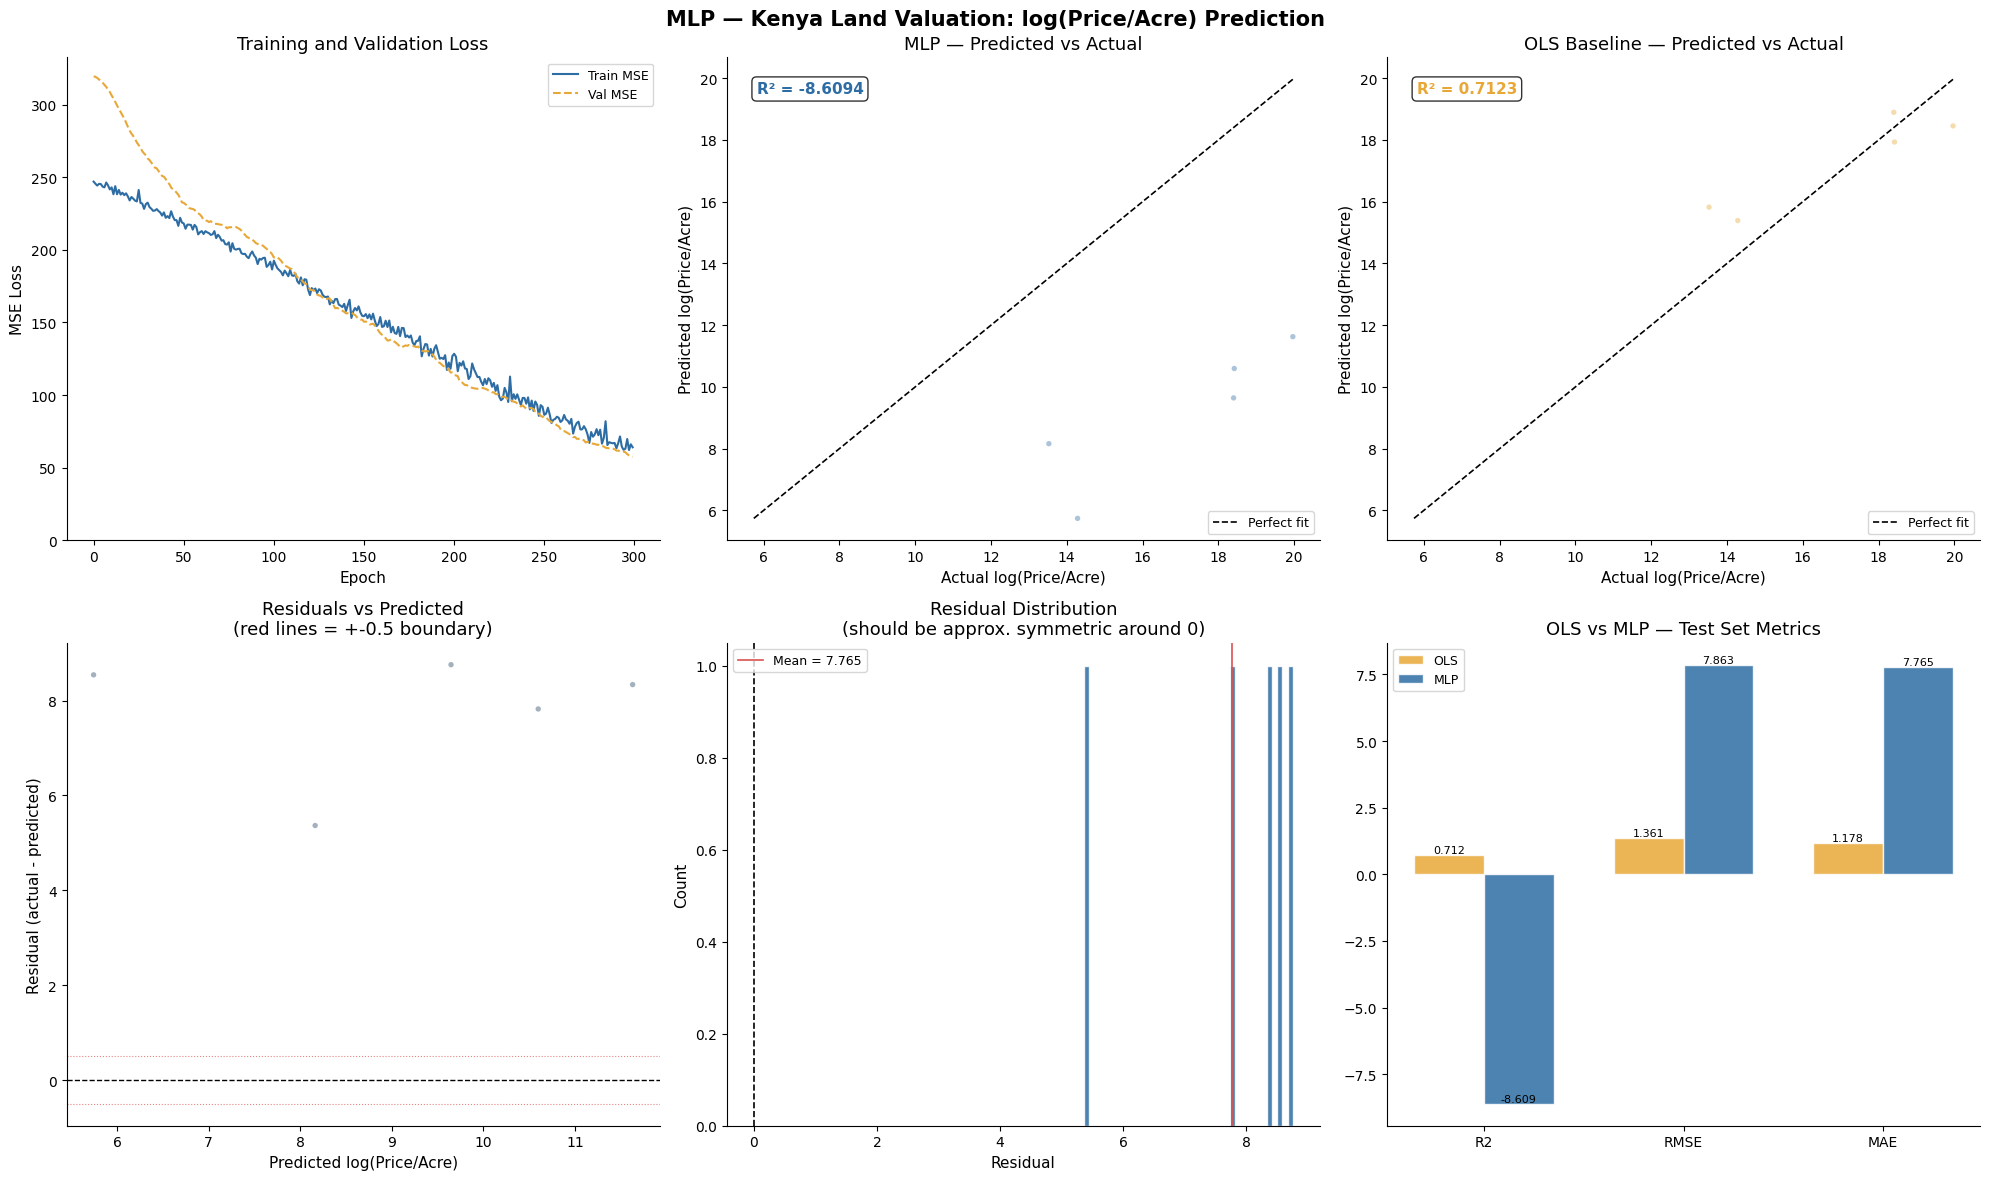

Chart saved to outputs folder.


In [33]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("MLP — Kenya Land Valuation: log(Price/Acre) Prediction",
             fontsize=15, fontweight="bold")

# 1. Training and validation loss curves
ax = axes[0, 0]
ax.plot(train_losses, color=BLUE, linewidth=1.5, label="Train MSE")
ax.plot(val_losses,   color=ORANGE, linewidth=1.5, linestyle="--", label="Val MSE")
ax.set_title("Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

# 2. Predicted vs actual — MLP
ax = axes[0, 1]
ax.scatter(y_test, mlp_test_pred, alpha=0.4, s=15, color=BLUE, edgecolors="none")
mn = min(y_test.min(), mlp_test_pred.min())
mx = max(y_test.max(), mlp_test_pred.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.2, label="Perfect fit")
ax.text(0.05, 0.95, f"R² = {mlp_test_r2:.4f}",
        transform=ax.transAxes, fontsize=11, fontweight="bold",
        color=BLUE, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.set_title("MLP — Predicted vs Actual")
ax.set_xlabel("Actual log(Price/Acre)")
ax.set_ylabel("Predicted log(Price/Acre)")
ax.legend(fontsize=9)

# 3. Predicted vs actual — OLS (reference)
ax = axes[0, 2]
ax.scatter(y_test, ols_test_pred, alpha=0.4, s=15, color=ORANGE, edgecolors="none")
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.2, label="Perfect fit")
ax.text(0.05, 0.95, f"R² = {ols_test_r2:.4f}",
        transform=ax.transAxes, fontsize=11, fontweight="bold",
        color=ORANGE, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.set_title("OLS Baseline — Predicted vs Actual")
ax.set_xlabel("Actual log(Price/Acre)")
ax.set_ylabel("Predicted log(Price/Acre)")
ax.legend(fontsize=9)

# 4. Residuals vs predicted (homoscedasticity check)
ax = axes[1, 0]
ax.scatter(mlp_test_pred, residuals, alpha=0.4, s=15, color=DARK, edgecolors="none")
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.axhline( 0.5, color=RED, linewidth=0.8, linestyle=":", alpha=0.7)
ax.axhline(-0.5, color=RED, linewidth=0.8, linestyle=":", alpha=0.7)
ax.set_title("Residuals vs Predicted\n(red lines = +-0.5 boundary)")
ax.set_xlabel("Predicted log(Price/Acre)")
ax.set_ylabel("Residual (actual - predicted)")

# 5. Residual distribution
ax = axes[1, 1]
ax.hist(residuals, bins=40, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.axvline(residuals.mean(), color=RED, linewidth=1.2, linestyle="-",
           label=f"Mean = {residuals.mean():.3f}")
ax.set_title("Residual Distribution\n(should be approx. symmetric around 0)")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# 6. OLS vs MLP metric comparison
ax = axes[1, 2]
metrics     = ["R2", "RMSE", "MAE"]
ols_vals    = [ols_test_r2,   ols_test_rmse, ols_test_mae]
mlp_vals    = [mlp_test_r2,   mlp_test_rmse, mlp_test_mae]
x           = np.arange(len(metrics))
width       = 0.35
bars_ols    = ax.bar(x - width/2, ols_vals, width, label="OLS",
                     color=ORANGE, edgecolor="white", alpha=0.85)
bars_mlp    = ax.bar(x + width/2, mlp_vals, width, label="MLP",
                     color=BLUE,   edgecolor="white", alpha=0.85)
ax.set_title("OLS vs MLP — Test Set Metrics")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=9)
for bar in list(bars_ols) + list(bars_mlp):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/mlp_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs folder.")

## Cell M10 — Save Model

Saves four artefacts needed to reproduce predictions on new data:

- `mlp_model.pt` — the PyTorch model weights (state dict)
- `mlp_scaler.pkl` — the fitted StandardScaler (must be applied before inference)
- `mlp_feature_list.pkl` — the ordered list of feature names (ensures column alignment)
- `mlp_results.csv` — the test set metric summary for reporting

To load and use the model later:
```python
scaler    = joblib.load("mlp_scaler.pkl")
features  = joblib.load("mlp_feature_list.pkl")
model     = MLP(input_dim=len(features))
model.load_state_dict(torch.load("mlp_model.pt"))
model.eval()
```


In [35]:
import joblib, numpy as np
import sklearn
print(f"numpy: {np.__version__}, sklearn: {sklearn.__version__}")
joblib.dump(scaler,        f"{MODEL_DIR}/mlp_scaler.pkl",        compress=0)
joblib.dump(MLP_FEATURES,  f"{MODEL_DIR}/mlp_feature_list.pkl",  compress=0)
joblib.dump([128, 64, 32], f"{MODEL_DIR}/mlp_hidden_layers.pkl", compress=0)
torch.save(mlp_model.state_dict(), f"{MODEL_DIR}/mlp_model.pt")

# Save results summary
results_df = pd.DataFrame({
    "model"     : ["OLS Baseline", "MLP"],
    "R2"        : [ols_test_r2,   mlp_test_r2],
    "RMSE"      : [ols_test_rmse, mlp_test_rmse],
    "MAE"       : [ols_test_mae,  mlp_test_mae],
})
results_df.to_csv(f"{OUTPUTS}/mlp_results.csv", index=False)
print(f"Saved: mlp_results.csv")

print("\n" + "=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"Model         : MLP  ({sum(p.numel() for p in mlp_model.parameters()):,} parameters)")
print(f"Features      : {len(MLP_FEATURES)}")
print(f"Train records : {len(X_train):,}")
print(f"Test R²       : {mlp_test_r2:.4f}")
print(f"Test RMSE     : {mlp_test_rmse:.4f}")
print(f"Test MAE      : {mlp_test_mae:.4f}")
print(f"OLS R² (ref)  : {ols_test_r2:.4f}")
print(f"R² gain       : {mlp_test_r2 - ols_test_r2:+.4f}")
print(f"\nAll artefacts saved to: {MODEL_DIR}")

numpy: 2.0.2, sklearn: 1.6.1
Saved: mlp_results.csv

FINAL SUMMARY
Model         : MLP  (12,097 parameters)
Features      : 9
Train records : 22
Test R²       : -8.6094
Test RMSE     : 7.8633
Test MAE      : 7.7651
OLS R² (ref)  : 0.7123
R² gain       : -9.3217

All artefacts saved to: /content/drive/MyDrive/kenya_land_valuation/models
